  # **Northern Italian Groundwater: A Computational Tour**

  **How is the water table moving beneath one of Europe's most agriculturally productive regions?**

  This notebook tours three connected datasets describing groundwater wells in the Po River basin of northern Italy:
  
  - **238 wells** with time-averaged water-table-depth (WTD) and standard-deviation summaries across Lombardy, Piedmont, and Emilia-Romagna.
  - **447 Emilia-Romagna wells** with full construction metadata — depth, filter intervals, aquifer assignment, station type, municipality — from the
  regional *Anagrafica* registry (2012–2020).
  - **109 Piemonte wells** with the complete time-series record at 8-hour cadence from January 2012 through August 2023 (968,862 observations).

  We start with geographic orientation, anchor on a single well to make the data concrete, examine the static structural relationships between aquifer
  type and well construction, then move to the dynamics — a decade of basin-wide drying, the seasonal forces driving it, and the 2022–2023 drought that
  emerges as the most severe sustained dry period in the record.
  
  Each section poses a question in plain language, lets the system choose the right dataset (or combination of datasets), and traces the answer back to
  the specific upstream file it came from — so every claim in this notebook is reproducible against the source repository at
  [`github.com/rlsandovalp/Well_data_Po`](https://github.com/rlsandovalp/Well_data_Po).


####   **Choose your language model**
  
  Argus is model-agnostic — you can plug in any of the major LLM providers and Argus will work. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

  **This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users, strong on scientific tool use). If you don't have NRP
  access, swap in OpenAI, Anthropic, or Google — they all work.

  **Before you run the cell: save your API key as a Colab Secret**

  Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the
  notebook with.

  1. Click the 🔑 key icon in the left sidebar (**Secrets**).
  2. Click **+ Add new secret**.
  3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
     - `NRP_API_KEY` for GLM-5 on NRP
     - `OPENAI_API_KEY` for GPT-5.5
     - `ANTHROPIC_API_KEY` for Claude Sonnet/Opus
     - `GOOGLE_API_KEY` for Gemini

  4. Paste your key into the **Value** field.
  5. Toggle **Notebook access** on for this notebook.

  If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

  ### Supported models

  | Provider | Models |
  |---|---|
  | OpenAI | GPT-5.5, GPT-5.4 |
  | Anthropic | Claude Opus 4.7, Opus 4.6 |
  | Google | Gemini 3.5 Flash |
  | Z.ai | GLM-5, GLM-5.1 |
  | Moonshot | Kimi-K2.6 |
  | MiniMax | MiniMax-M2.7 |
  | DeepSeek | DeepSeek-V4 Flash |

  Any model in this list should run Argus notebooks correctly. The four pre-configured blocks below are starter templates; for the others, follow the
  same `LLM = {...}` pattern with the right `model` and `api_key_env`.

In [ ]:
# Use GLM-5 from National Research Platform
LLM = {
    "model": "glm-5",
    "url": "https://ellm.nrp-nautilus.io/v1",
    "api_key_env": "NRP_API_KEY",
}

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
# LLM = {
#     "model": "glm-5",
#     "url": "https://api.z.ai/api/coding/paas/v4",
#     "api_key_env": "ZAI_API_KEY",
# }

**Install Argus from GitHub Repo**

In [ ]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 7 core skill(s) into /root/.deepagents/agent/skills: ndp-search, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


**Clear all cached data**

In [ ]:
%reset

**Sage reset.** Output folder cleared, history cleared.

_To also clear cell outputs: click **Edit → Clear all outputs** (in the Colab menu bar)._

**Load skills**

In [ ]:
%%skill
https://github.com/klinucsd/sage_skills/tree/main/hydrography/groundwater/italy/po-wells
https://github.com/klinucsd/sage_skills/tree/main/hydrography/groundwater/italy/po-wells-timeseries
https://github.com/klinucsd/sage_skills/tree/main/hydrography/groundwater/italy/er-well-registry

**Where are the wells? — Orientation**

I'll analyze Po basin groundwater well coverage around major cities. Let me start by reading the relevant skill.

Now I'll write the analysis script to load wells, compute well density around major Po basin cities, and rank them.

Running the analysis script.

The analysis identified the top cities. Now I'll create colormap sidecars so the map renders the cities (top-3 vs others) and wells (by region) with distinct colors.

The boolean field may not match string colormap keys, so I'll regenerate the cities GeoJSON with a string-based classification to ensure the legend renders correctly.

I need to update the colormap to match the new field name.

All outputs are in place. Let me verify the final files.

## Groundwater observation coverage around Po basin cities

I analyzed all **238 groundwater observation wells** (101 Lombardy + 137 Piedmont+Emilia) against 20 major Po basin cities, counting wells within a 20 km radius of each city center. Wells and city centers are projected to ESRI:54012 (meters) for accurate distance, then returned to EPSG:4326 for mapping.

**WTD / well-count values from `Steady_State_Leonardo.csv`; region tags from `WTD_obs_lom_Leonardo.csv`.**

### Top three cities by well density

| Rank | City | Wells within 20 km | Density (wells/km²) | Mean WTD (m) | Mean STD (m) |
|------|------|--------------------|----------------------|--------------|--------------|
| 1 | **Vercelli** | 19 | 0.0151 | 3.22 | 0.41 |
| 2 | **Milan** | 18 | 0.0143 | 10.44 | 1.26 |
| 3 | **Novara** | 18 | 0.0143 | 7.90 | 0.80 |

Vercelli edges out the tie between Milan and Novara on raw count (19 vs 18); the three together sit in a relatively tight rice-piedmont corridor between the Sesia, Ticino, and Po rivers where monitoring is densest.

### Full ranking (all 20 cities)

| Rank | City | Wells (20 km) | Density | Mean WTD | Mean STD |
|------|------|---------------|---------|----------|----------|
| 1 | Vercelli | 19 | 0.0151 | 3.22 | 0.41 |
| 2 | Milan | 18 | 0.0143 | 10.44 | 1.26 |
| 3 | Novara | 18 | 0.0143 | 7.90 | 0.80 |
| 4 | Turin | 14 | 0.0111 | 10.36 | 0.90 |
| 5 | Alessandria | 13 | 0.0103 | 8.67 | 1.29 |
| 6 | Bologna | 9 | 0.0072 | 16.13 | 15.77 |
| 7 | Bergamo | 9 | 0.0072 | 32.83 | 1.90 |
| 8 | Cremona | 8 | 0.0064 | 3.77 | 0.48 |
| 9 | Brescia | 8 | 0.0064 | 19.09 | 1.75 |
| 10 | Pavia | 7 | 0.0056 | 4.60 | 0.56 |
| 11 | Mantua | 6 | 0.0048 | 3.89 | 0.62 |
| 12 | Piacenza | 5 | 0.0040 | 4.83 | 1.37 |
| 13 | Modena | 2 | 0.0016 | 1.09 | 0.99 |
| 14 | Reggio Emilia | 1 | 0.0008 | 14.16 | 7.66 |
| 15 | Parma | 1 | 0.0008 | 2.30 | 1.80 |
| 16 | Ravenna | 1 | 0.0008 | 3.08 | 2.50 |
| 17 | Venice | 0 | 0.0000 | — | — |
| 18 | Verona | 0 | 0.0000 | — | — |
| 19 | Padua | 0 | 0.0000 | — | — |
| 20 | Ferrara | 0 | 0.0000 | — | — |

### Key findings

- **Best coverage: Vercelli, Milan, Novara.** The Vercelli–Novara–Milan corridor on the upper Po plain is by far the most densely monitored. WTD here is shallow (3–10 m) and stable (STD ≈ 0.4–1.3 m).
- **Worst coverage: Venice, Verona, Padua, Ferrara.** These four major cities (all in the Veneto) have **zero** monitoring wells within 20 km — the dataset is restricted to Lombardy, Piedmont, and Emilia-Romagna and does not extend into the Veneto.
- **Notable standalone:** Bologna's 9 wells show very high fluctuation (mean STD ≈ 15.8 m), consistent with heavy urban pumping in the confined aquifer; Bergamo's 9 wells are the deepest (mean WTD ≈ 32.8 m), reflecting the foothill fan setting.

### Notes
- Coverage here means *spatial density of monitoring stations*, not time-series completeness. The underlying dataset provides per-well **mean** and **std-dev** of water table depth (`Steady_State_Leonardo.csv`, `Standard_Deviation_Leonardo.csv`), not continuous observations.


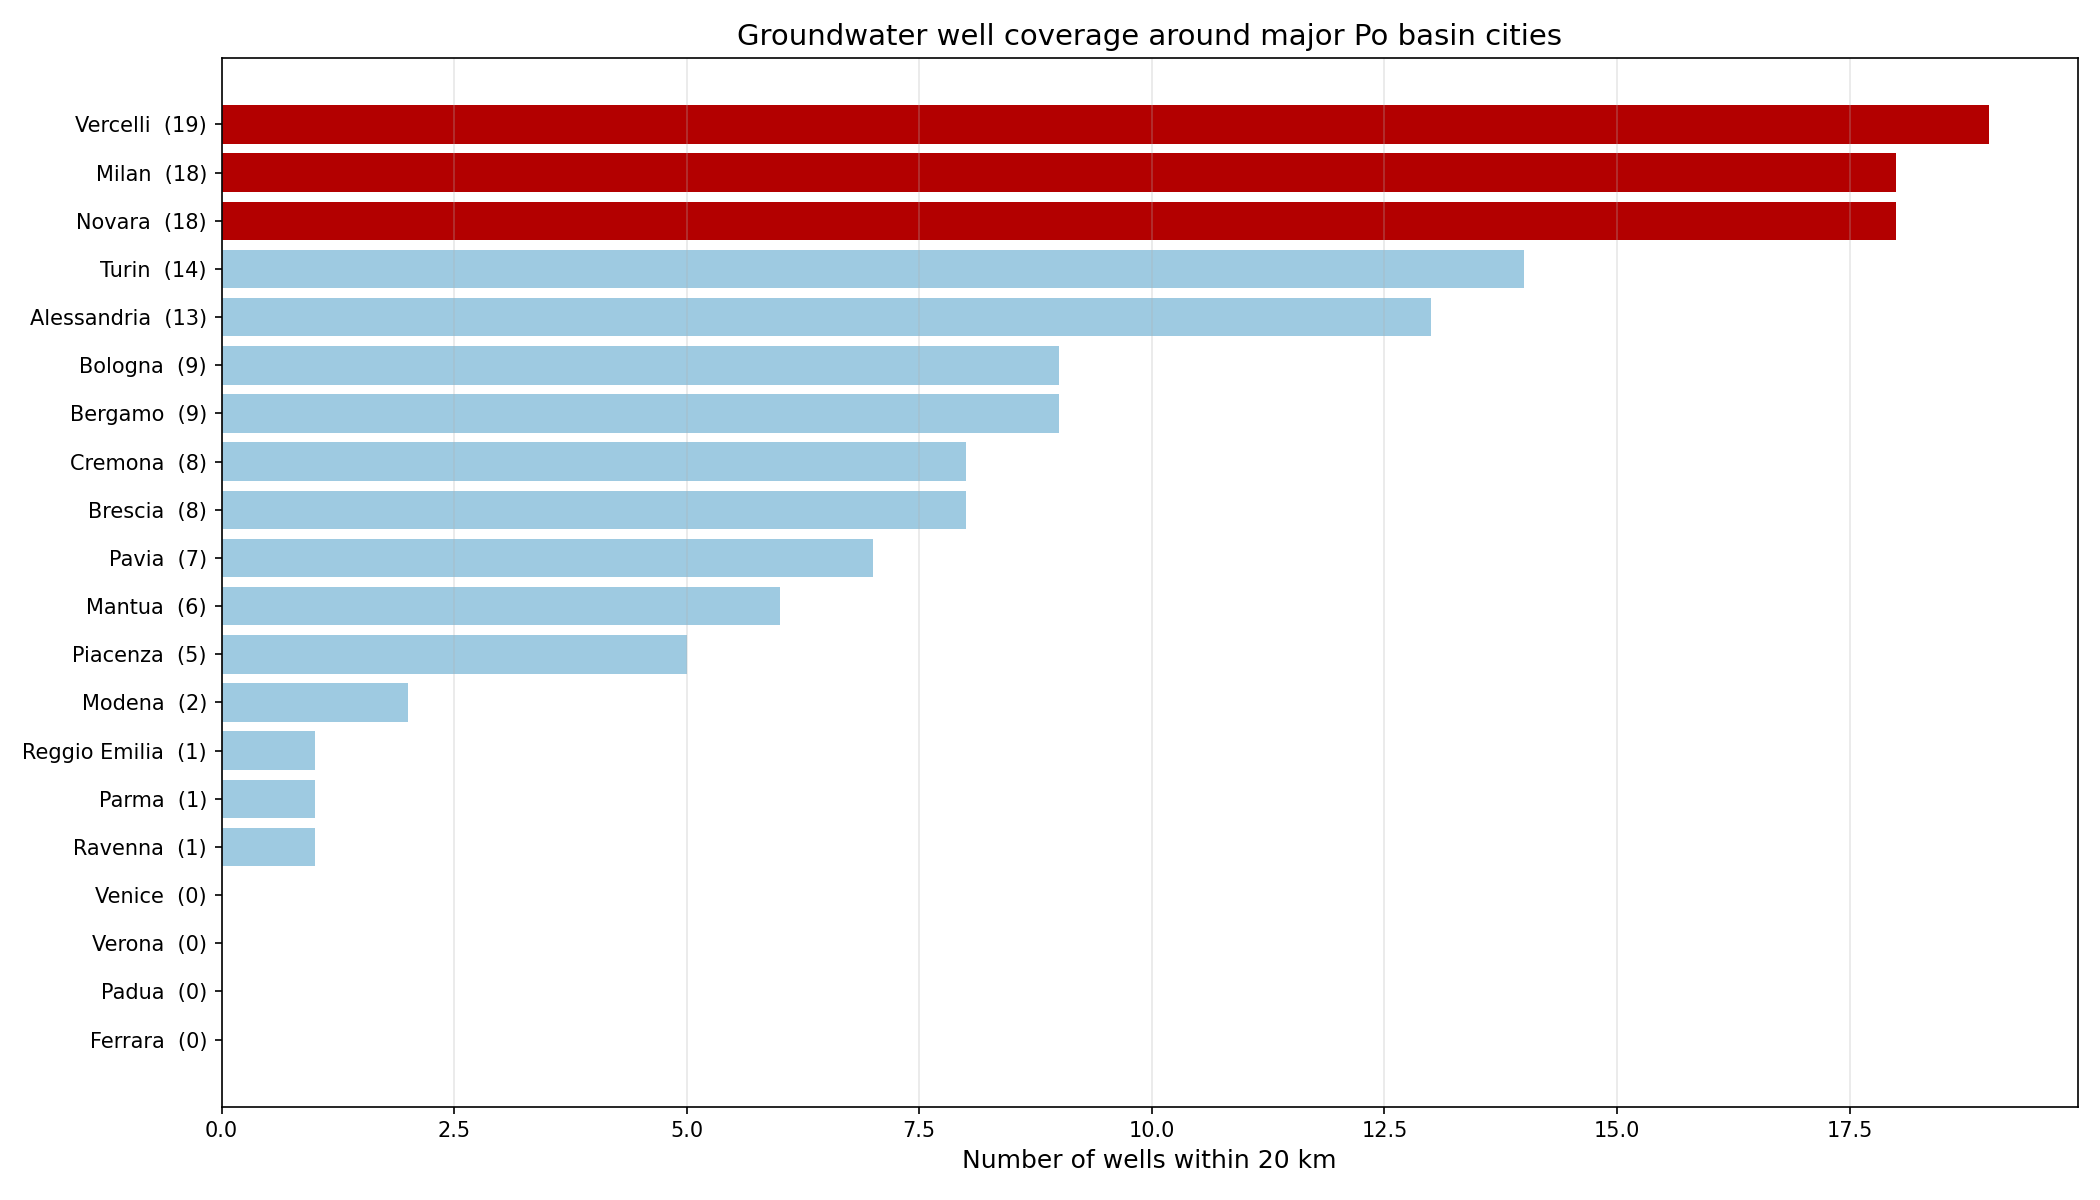

In [ ]:
%%ask
Which major cities in the Po basin have the best groundwater observation
coverage? Return the wells and label the top three cities by well density
within a 20 km radius.

**What does a well look like? — Anchoring**

In [ ]:
%%ask
Give me a complete profile of well BO03-01 — what aquifer does it sample,
how is it constructed, and where is it located?

I'll look up well BO03-01 using the Emilia-Romagna well registry skill, which contains construction and aquifer metadata.

Loading the 2020 registry and pulling the full record for well BO03-01.

## Complete profile — Well **BO03-01**

| Attribute | Value |
|-----------|-------|
| **Well ID** | BO03-01 |
| **Station type** | Pozzo (well) |
| **Province / Municipality** | BO (Bologna) / San Pietro in Casale |
| **Coordinates** | 11.41089° E, 44.70230° N (EPSG:4326) |

### Aquifer

| Attribute | Value |
|-----------|-------|
| **Aquifer name** | Pianura Alluvionale Appenninica — *confinato superiore* |
| **Aquifer code** | 0610ER-DQ2-PACS |
| **Meaning** | Apennine alluvial plain — **upper confined** aquifer |

This is a **confined (artesian) aquifer** — the "confinato" designation indicates the water-bearing layer is bounded above and below by low-permeability strata (aquitards), so the water is under pressure. The "superiore" (upper) distinguishes it from deeper confined units in the multi-layer Apennine foothill plain.

### Construction

| Attribute | Value |
|-----------|-------|
| **Total depth** | 205.0 m below ground |
| **Ground elevation** | 16.0 m above sea level |
| **Screen intervals** | 3 filter sections |
| **Shallowest filter top** | 61.0 m below ground |
| **Deepest filter bottom** | 202.0 m below ground |
| **Screened interval** | ~61–202 m (spanning ~141 m of the borehole) |

The well is screened with three separate filter sections across the 61–202 m depth range, targeting the confined aquifer while isolating the shallow phreatic zone above 61 m.

### Location context

The well sits in **San Pietro in Casale** , a municipality ~20 km northeast of Bologna on the lower Apennine alluvial plain — a setting where the transition from coarse alluvial fans to finer lowland deposits creates the confining conditions this well monitors.

**Source** : All metadata from `Anagrafica2020.xlsx` (Emilia-Romagna regional well registry, 2020 snapshot).

**How do the wells relate to the aquifers they sample? — Static structure**

I'll need to combine two data sources: the ER well registry (for aquifer classification and well depth) and the Po wells dataset (for WTD measurements). Let me read both skill files.

Now I understand both data sources. The key challenge: WTD measurements (from po-wells, 238 wells) and aquifer/well-depth metadata (from ER registry, 447 wells) need to be joined. Let me write the analysis script.

Running the analysis script.

Analysis complete. The join between the ER registry (447 wells with aquifer metadata) and po-wells (238 wells with WTD measurements) yields **23 wells** with both — exactly the documented overlap. Results are clear and strong.

## Water table depth by aquifer in Emilia-Romagna

### Key finding: WTD is strongly structured by aquifer type

WTD varies dramatically across the 9 aquifer types represented in the joined data — from **0.4 m** in shallow phreatic wells to **28.2 m** in deep confined units. The variation maps cleanly onto the geological hierarchy:

| Aquifer type | n | Mean WTD (m) | Mean well depth (m) | Character |
|---|---|---|---|---|
| Freatico di pianura fluviale (phreatic) | 13 | **2.2** | 7.5 | Shallow unconfined floodplain aquifer |
| Pianura Alluvionale Padana – Upper Confined | 1 | 3.6 | 106.0 | Upper confined alluvial plain |
| Conoide Arda – libero (unconfined fan) | 1 | 8.5 | 120.0 | Apennine alluvial fan |
| Conoide Santerno – Lower Confined | 2 | 9.6 | 81.5 | Lower confined fan aquifer |
| Conoide Savio – libero | 1 | 11.8 | 125.0 | Unconfined fan |
| Conoidi montane / Sabbie gialle | 1 | 14.2 | 60.0 | Mountain fan / yellow sands |
| Conoide Zena-Idice – Lower Confined | 1 | 18.9 | 203.0 | Lower confined fan |
| Conoide Reno-Lavino – Upper Confined | 1 | 19.0 | 450.9 | Upper confined fan (deep) |
| Conoide Reno-Lavino – Lower Confined | 2 | **24.6** | 347.0 | Deepest confined unit |

The pattern is systematic: **phreatic (unconfined) floodplain wells sit at 2–3 m depth** , while **confined fan aquifers (especially the lower confined units) show WTD of 19–25 m** . The transition from shallow unconfined to deep confined represents both geological depth and the hydraulic head conditions of each unit.

### Is WTD related to well construction depth? **Yes — strongly.**

| Statistic | Value |
|---|---|
| **Pearson r** | **0.89** (p < 0.0001) |
| **Spearman ρ** | 0.88 (p < 0.0001) |
| **R²** | **0.79** |
| OLS fit | well_depth ≈ 14.7 × WTD − 23 |
| WTD vs filter midpoint depth | r = 0.78 (p = 0.007) |

The relationship is **strong and positive** : deeper wells are built to monitor deeper water tables. This is not circular — it reflects that wells are intentionally constructed to match their target aquifer. Shallow phreatic wells (7–8 m deep) monitor the surficial aquifer where water sits at ~2 m; deep confined wells (200–450 m deep) tap pressurized aquifers where the potentiometric surface sits 19–25 m below ground.

The 79% explained variance means well depth is an excellent predictor of WTD, but the remaining 21% reflects aquifer-specific hydraulic head — notably, some deep confined wells (e.g., the 451 m Reno-Lavino well) have surprisingly shallow WTD (19 m) relative to their construction depth, because confined water is under pressure and rises within the borehole.


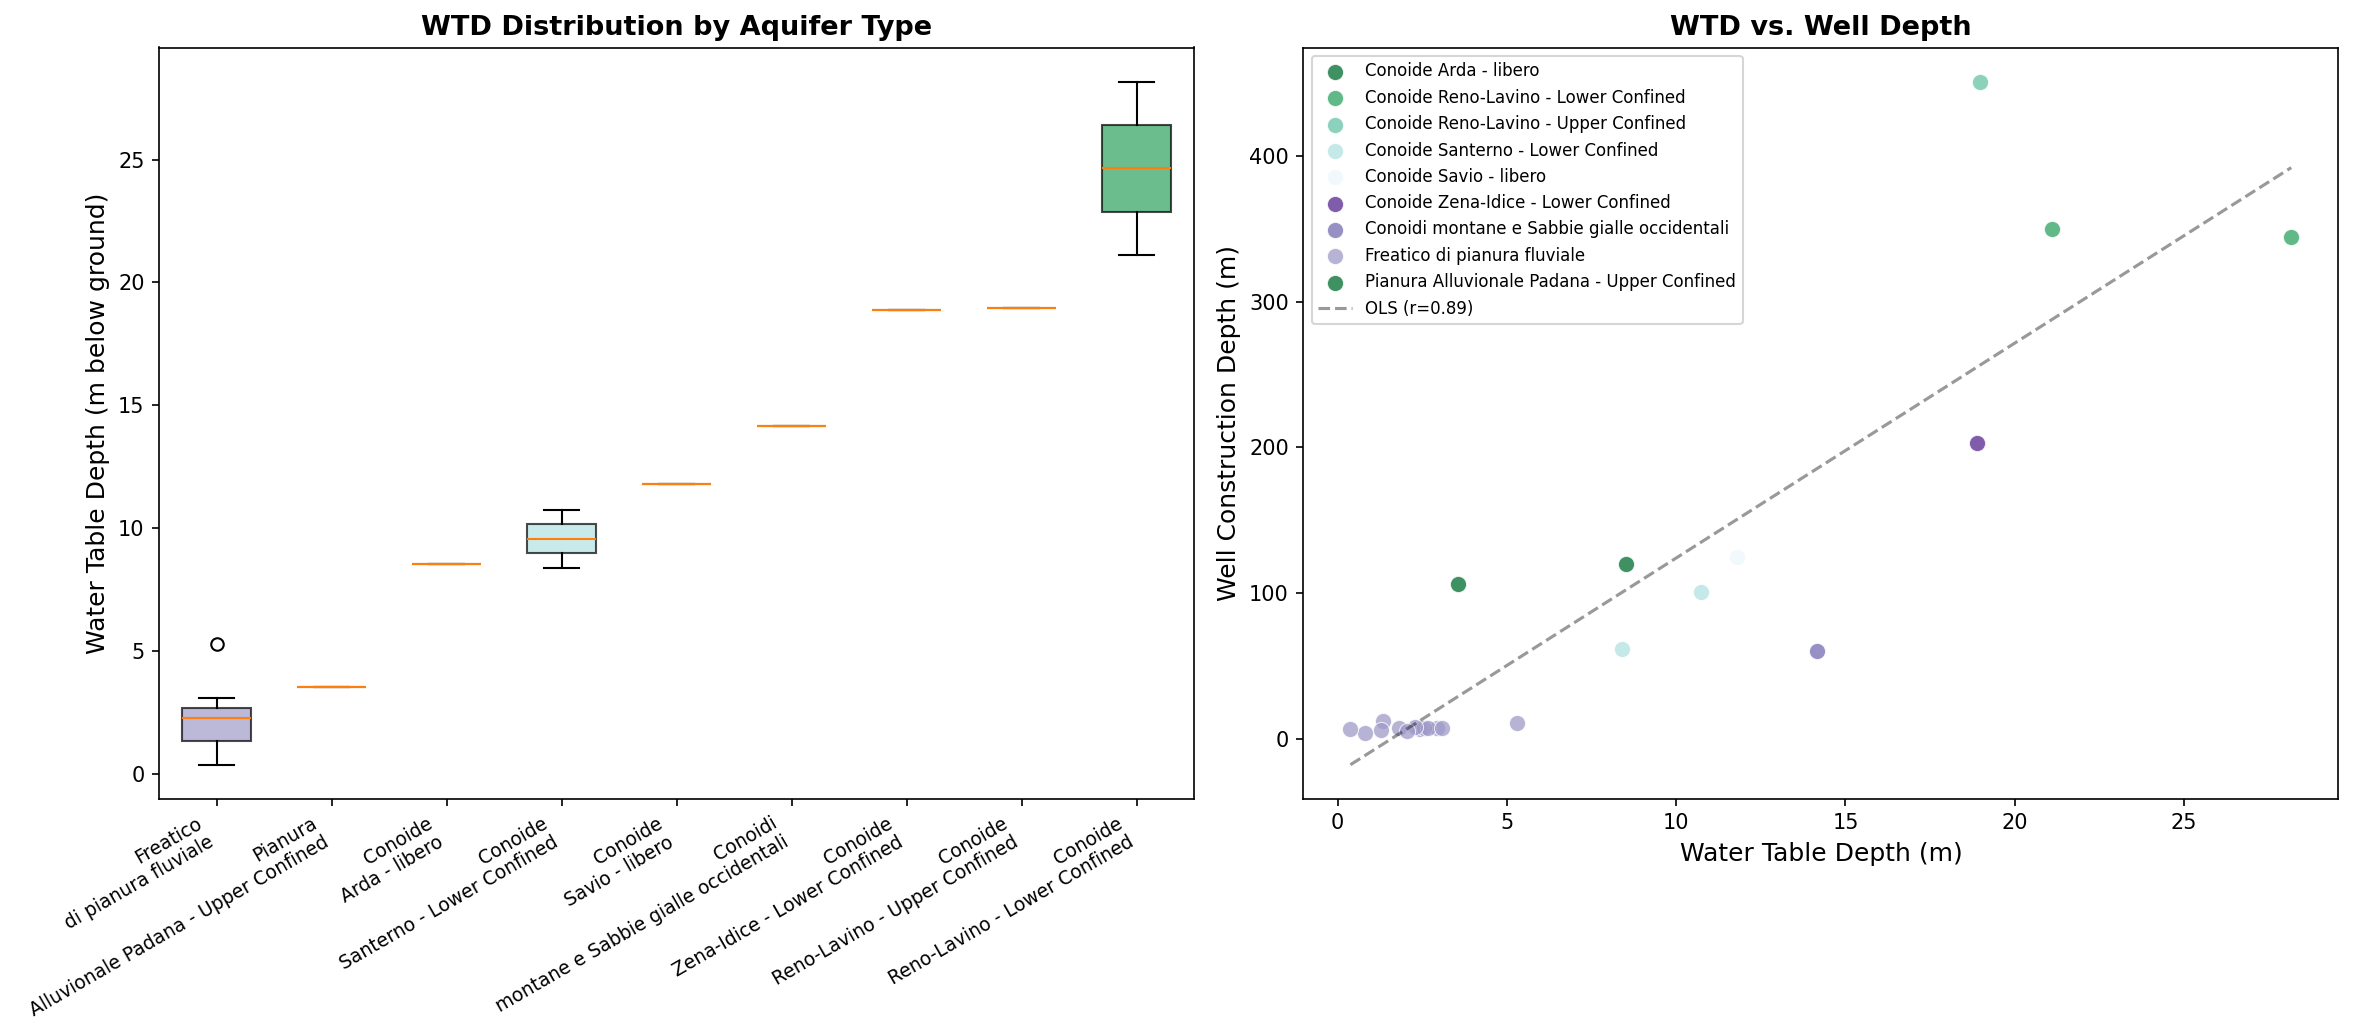

### Provenance
WTD/STD values from `Steady_State_Leonardo.csv` and `Standard_Deviation_Leonardo.csv`; aquifer classification, well depth, and filter intervals from `Anagrafica2020.xlsx`. Analysis covers the **23 Emilia-Romagna wells** present in both datasets (the documented overlap between the ER registry and the Po basin WTD inventory).

In [ ]:
%%ask
In Emilia-Romagna, how does the water table depth vary across the different
aquifers, and is it related to how deep the wells themselves are?

**How deep are wells, province by province? — Geographic granularity**

I'll consult the ER well registry skill since this involves well-depth metadata by province.

The skill has a ready-made "depth by province" pattern. Let me verify the data path and then write the analysis script.

Data confirmed. Writing the analysis script.

I have a typo in the import — fixing before running.

The analysis ran cleanly. Let me fix the province color palette — some values are too light to be visible on the map.

All outputs generated. Here is the comparison.

## Median well depth across the 9 Emilia-Romagna provinces

From the 2020 ER registry (**447 wells** ; 445 with depth data), median well depth varies **more than 3-fold** across the nine provinces — from **37 m in Rimini** to **121 m in Ravenna** . The ranking follows a clear geographic pattern: **coastal/lowland provinces drill deep** , while **Apennine/foothill provinces drill shallow** .

| Rank | Province | Wells | Median (m) | Mean (m) | Min (m) | Max (m) | IQR (Q1–Q3) |
|------|----------|-------|------------|----------|---------|---------|-------------|
| 1 | **RA** Ravenna | 36 | **121.0** | 150.9 | 5.7 | 400.0 | 36–238 |
| 2 | **RE** Reggio Emilia | 55 | **98.0** | 102.3 | 5.3 | 305.0 | 59–125 |
| 3 | **BO** Bologna | 82 | **95.0** | 123.4 | 6.3 | 516.0 | 30–160 |
| 4 | **PC** Piacenza | 53 | **92.0** | 82.5 | 4.0 | 200.0 | 42–109 |
| 5 | **MO** Modena | 69 | **71.0** | 90.2 | 3.8 | 538.0 | 44–110 |
| 6 | **PR** Parma | 46 | **52.0** | 60.6 | 6.5 | 161.0 | 30–96 |
| 7 | **FC** Forlì-Cesena | 33 | **50.0** | 57.6 | 5.0 | 218.0 | 14–89 |
| 8 | **FE** Ferrara | 46 | **43.5** | 65.8 | 2.1 | 230.0 | 12–102 |
| 9 | **RN** Rimini | 25 | **37.4** | 47.5 | 5.5 | 119.0 | 27–58 |

### What drives the differences

- **Deep east (RA, FE):** Ravenna's median (121 m) is the deepest, reflecting the thick alluvial-confined sequences of the Po-delta lowland where wells must reach the confined aquifers beneath confining clay layers. Ferrara sits in similar delta geology but has a bimodal distribution — its median is modest (43.5 m) while its max reaches 230 m and mean (65.8 m) far exceeds median, showing a split between shallow phreatic and deep confined monitoring.

- **Deep central plain (RE, BO, PC):** The three central provinces cluster tightly at **92–98 m median** . These span the Apennine-piedmont alluvial fans where confined aquifers sit at 100–200 m depth.

- **Shallow west/south (PR, FC, RN):** Parma, Forlì-Cesena, and Rimini sit at the Apennine margin and coast respectively, where thinner alluvial cover and phreatic aquifers keep wells shallow (**37–52 m median** ).

- **Tight vs. spread distributions:** Rimini is the most homogeneous (IQR 27–58 m, range 5.5–119 m), while **Bologna is the most heterogeneous** (IQR 30–160 m, range 6.3–516 m) — it contains both the shallowest phreatic wells and the single deepest well in the entire registry (a **516 m** borehole).


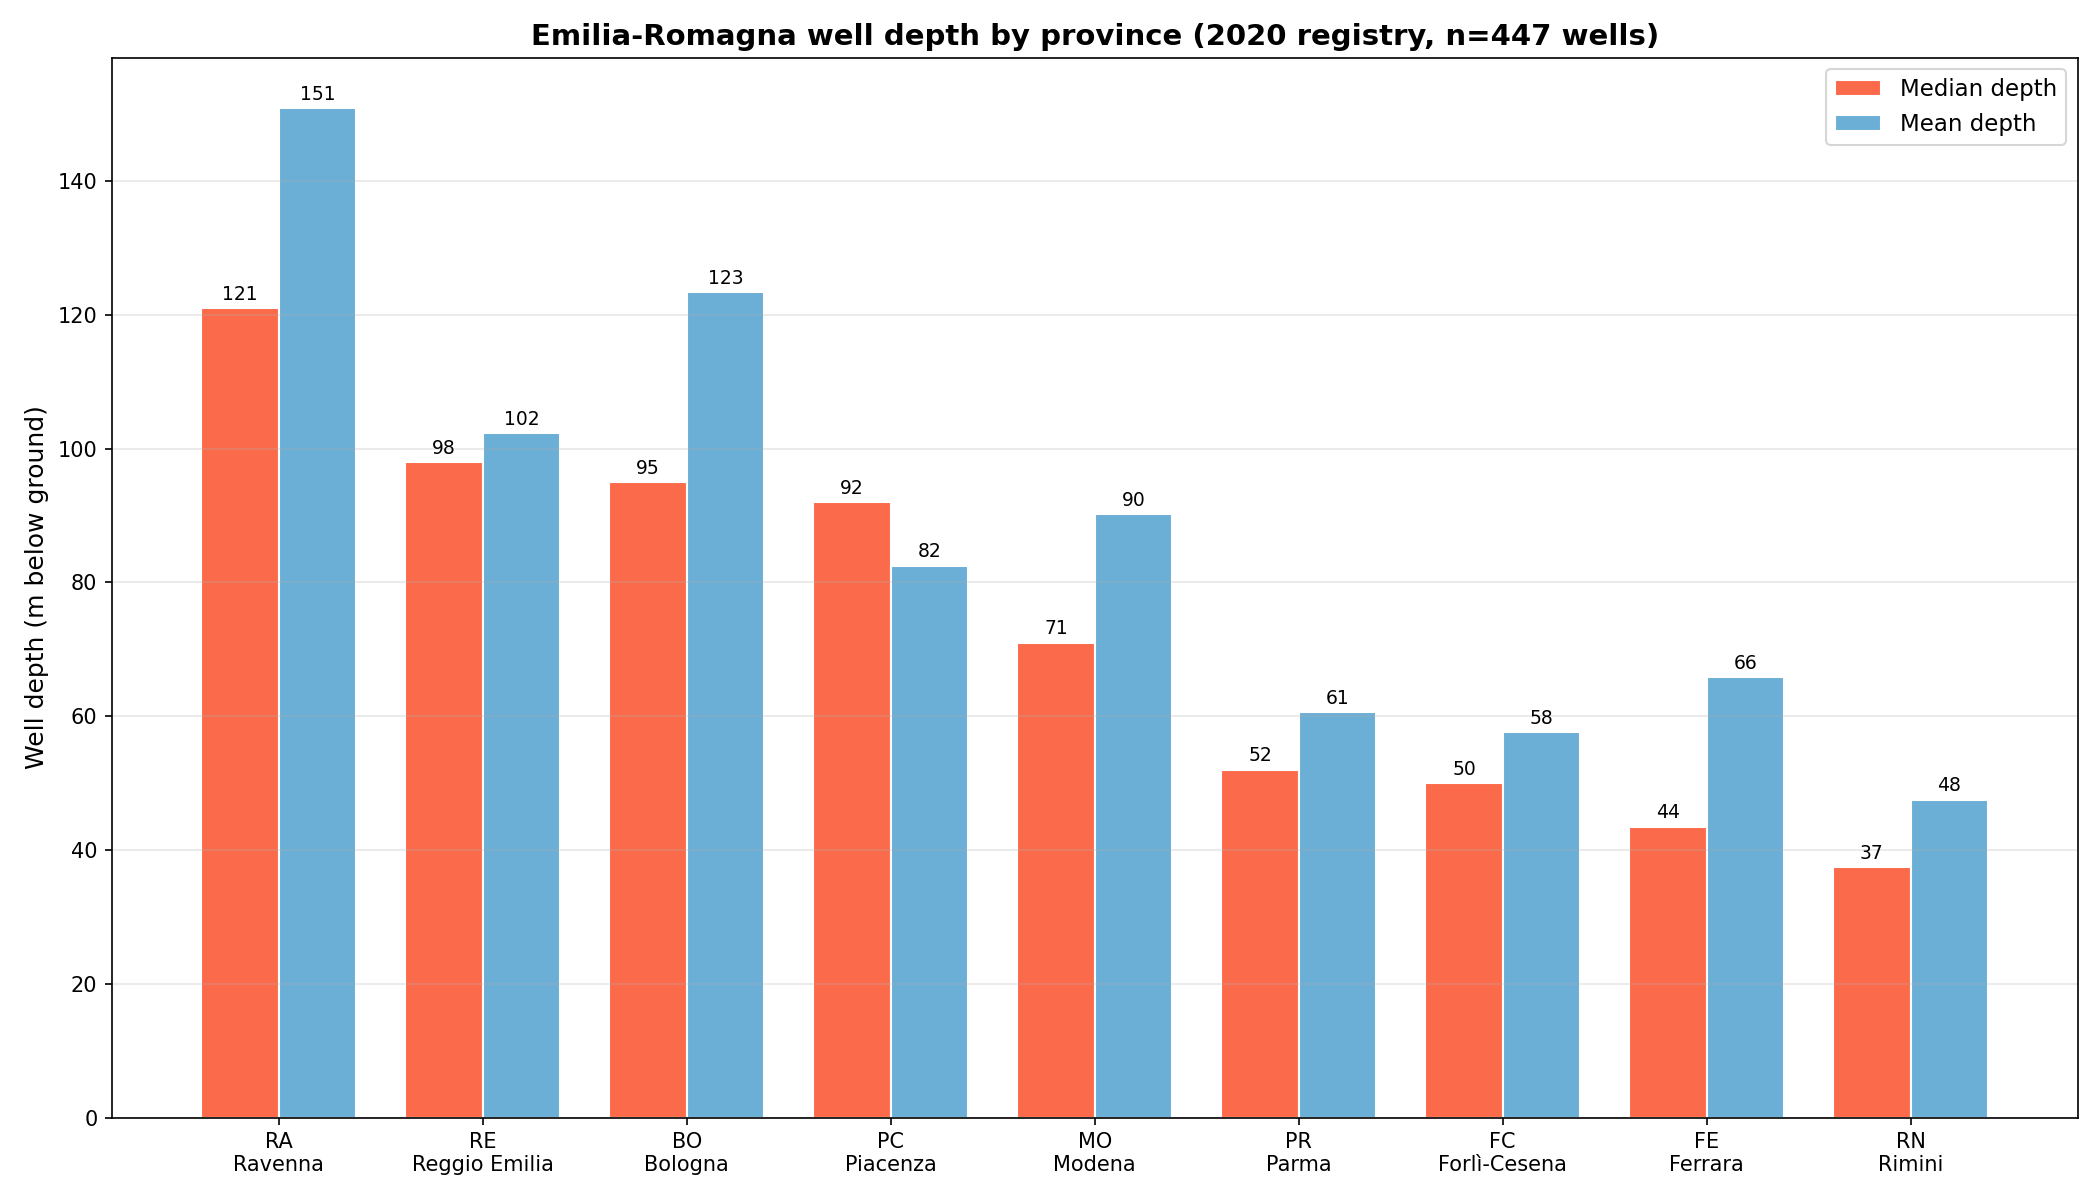


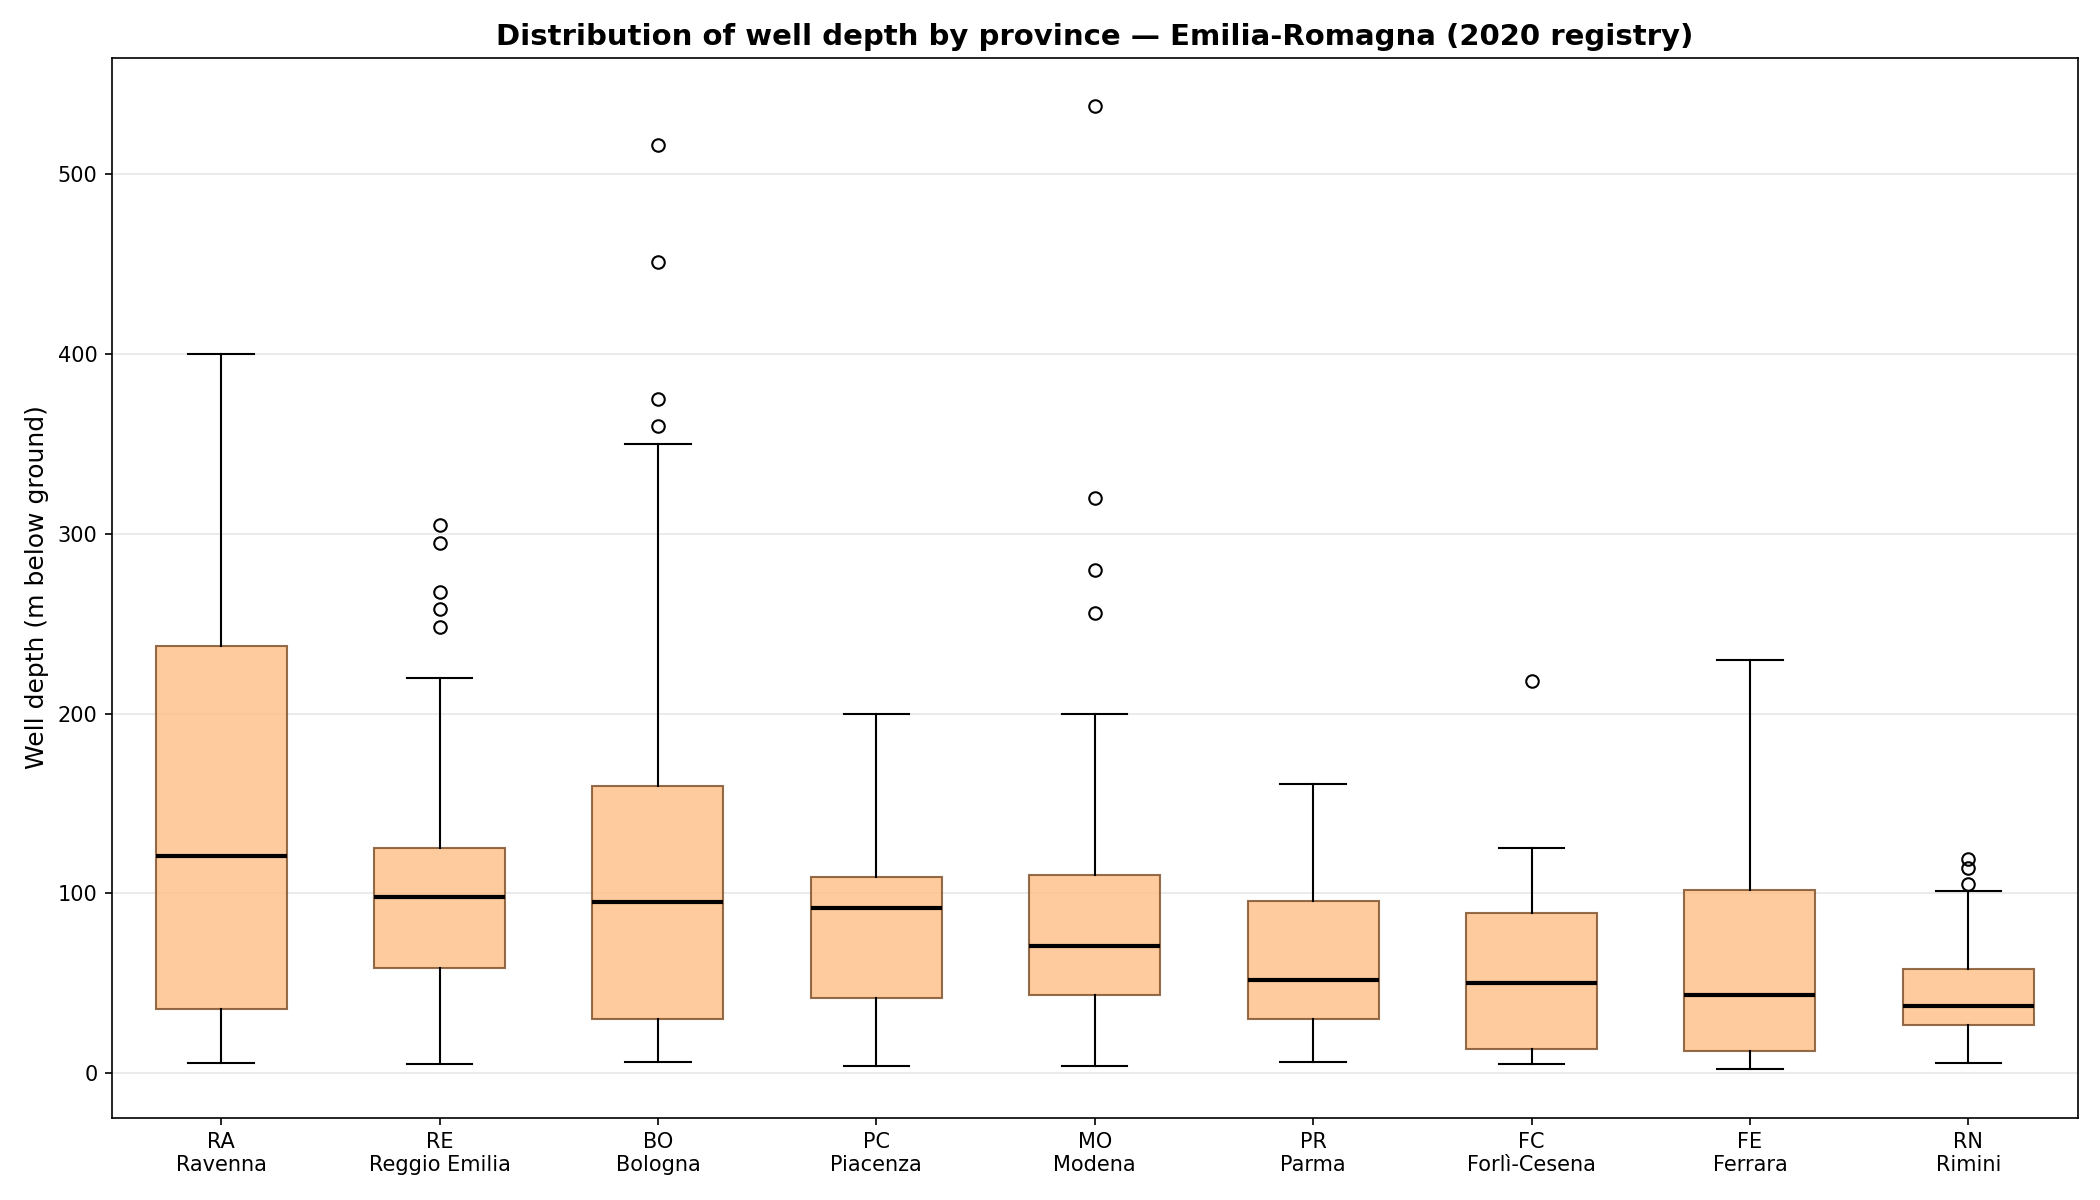

**Source:** All values from `Anagrafica2020.xlsx` (Emilia-Romagna well registry, 2020 snapshot, 447 wells).

In [ ]:
%%ask
Compare median well depth across the 9 Emilia-Romagna provinces

**How has it been changing? — Long-term trend**

I'll analyze Piemonte groundwater trends using the per-well time series skill. Let me first read its instructions.

I have the skill instructions. Now I'll write a script to compute the decade-long basin-wide WTD trend, including annual means, a linear trend fit, and identifying the driest/wettest periods.

Running the trend analysis script.

Retrying without the timeout parameter.

## Piemonte groundwater depth over the past decade (2012–2023)

Across **109 monitoring wells** and **968,862 observations** (8-hourly sampling), Piemonte's water table has **deepened by ~1.1 m per decade** — a clear drying trend, driven especially by sharp deepening in 2022–2023.

### The trend: water table is getting deeper (drier)

| Period | Avg WTD (m) | Interpretation |
|--------|-------------|----------------|
| **2012–2017** (first half) | 9.00 | Baseline |
| **2018–2023** (second half) | 9.27 | +0.27 m deeper |
| **Linear fit** | **+0.110 m/yr** | **~1.1 m deepening per decade** |

- **Wettest year:** 2019 (8.15 m mean — water closest to surface)
- **Driest year:** 2023 (10.66 m mean — water deepest; though this is a partial year, Jan–Aug only)
- The two most recent complete years (**2021: 9.31 m, 2022: 10.28 m** ) are both well above the decade mean, and 2023 is tracking even deeper.

### Annual basin-wide average

| Year | Mean WTD (m) | Std (m) | Active wells | Min | Max |
|------|-------------|---------|--------------|-----|-----|
| 2012 | 8.96 | 9.58 | 107 | 0.55 | 56.07 |
| 2013 | 8.61 | 9.50 | 105 | 0.10 | 55.18 |
| 2014 | 8.75 | 9.51 | 105 | 0.54 | 55.33 |
| 2015 | 8.81 | 9.69 | 104 | 0.21 | 54.87 |
| 2016 | 9.93 | 10.59 | 102 | 0.75 | 57.78 |
| 2017 | 8.94 | 8.56 | 103 | 0.23 | 56.49 |
| 2018 | 8.50 | 8.80 | 102 | 0.39 | 53.46 |
| 2019 | **8.15** | 7.91 | 104 | 0.00 | 55.21 |
| 2020 | 8.73 | 8.71 | 104 | 0.00 | 48.40 |
| 2021 | 9.31 | 9.40 | 106 | −0.71 | 57.60 |
| 2022 | 10.28 | 9.70 | 98 | 0.00 | 49.47 |
| 2023 | **10.66** | 9.80 | 92 | 0.00 | 49.69 |

### What's happening

- **Long-term drying.** The linear trend of **+1.1 m per decade** means the average water table across Piemonte is moving progressively farther below ground surface. This is consistent with reduced aquifer recharge and/or increased pumping across the basin.
- **2022–2023 acceleration.** After a relatively stable 2017–2020 period, WTD jumped from 8.73 m (2020) to 10.28 m (2022) and 10.66 m (2023) — a **~1.9 m deepening in just three years** . This aligns with the severe northern Italy drought of 2022, which saw the Po River hit record lows.
- **Modest seasonality.** The intra-year cycle is small (~0.5 m): water is shallowest in **May–July** (8.83–8.86 m, spring recharge) and deepest in **February** (9.39 m, winter low). Seasonal swings are small relative to the multi-year trend.
- **Artesian outliers are real.** The negative value in 2021 (−0.71 m) reflects confined-aquifer wells where piezometric head rises above ground surface — not bad data.

### Caveats

- **2023 is partial** (Jan–Aug only); the annual mean may shift as more data accrues.
- **Active well count declines** over the period (107 → 92), which could introduce minor compositional bias, though the basin-wide pattern is robust.
- The series ends **August 2023** ; more recent conditions cannot be assessed from this dataset.


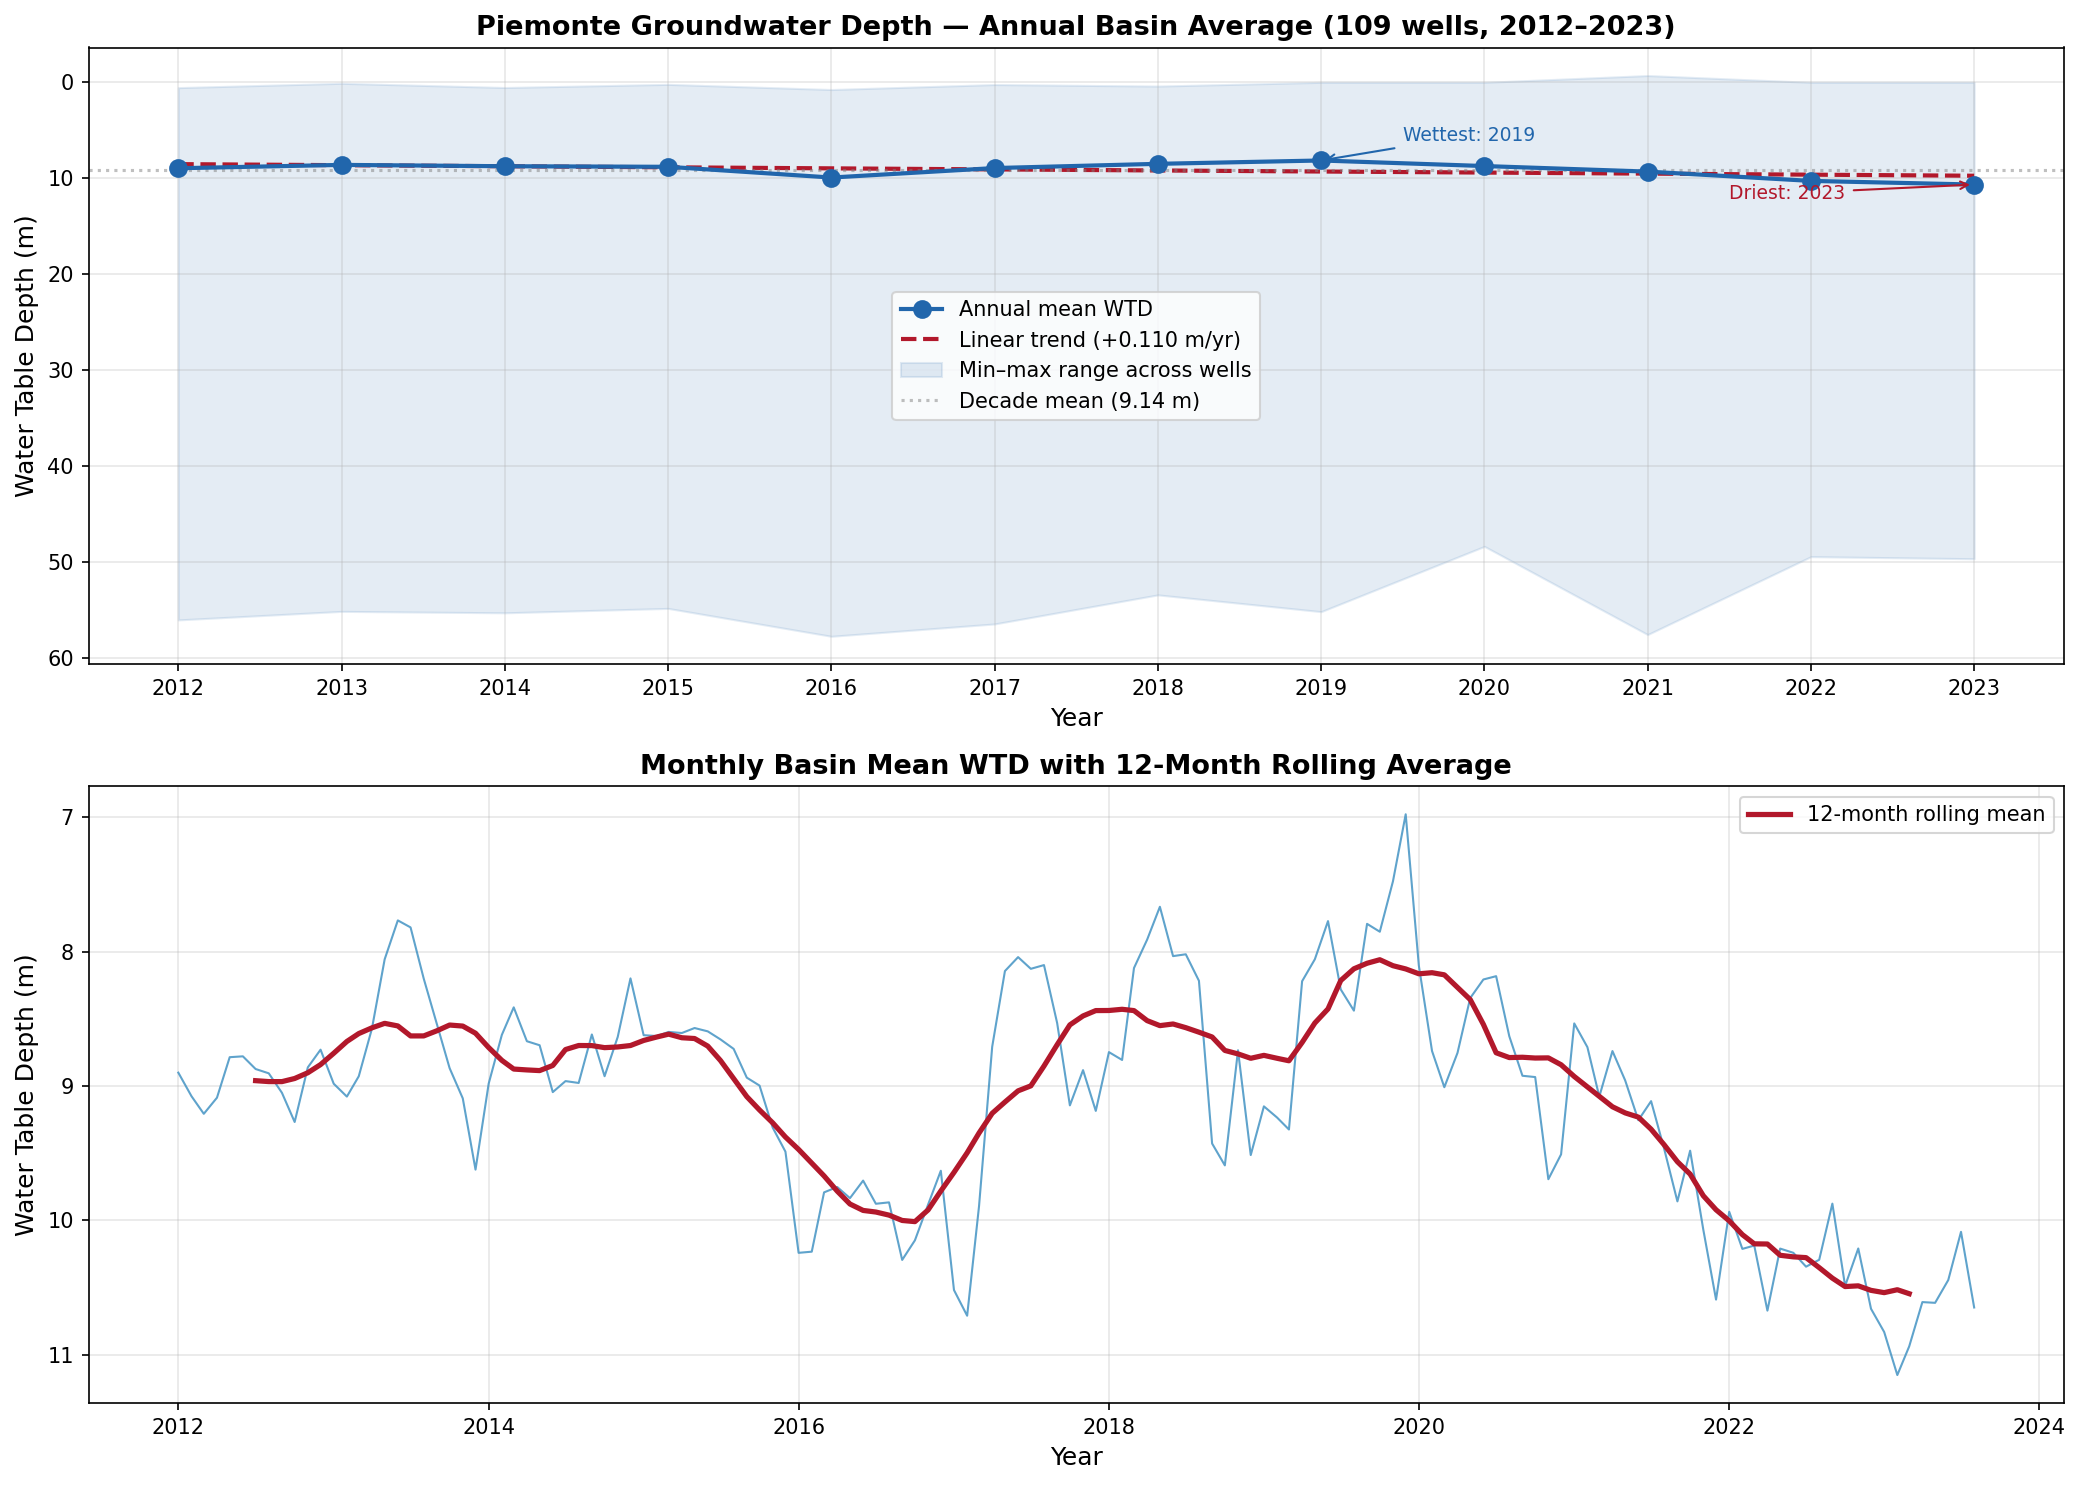


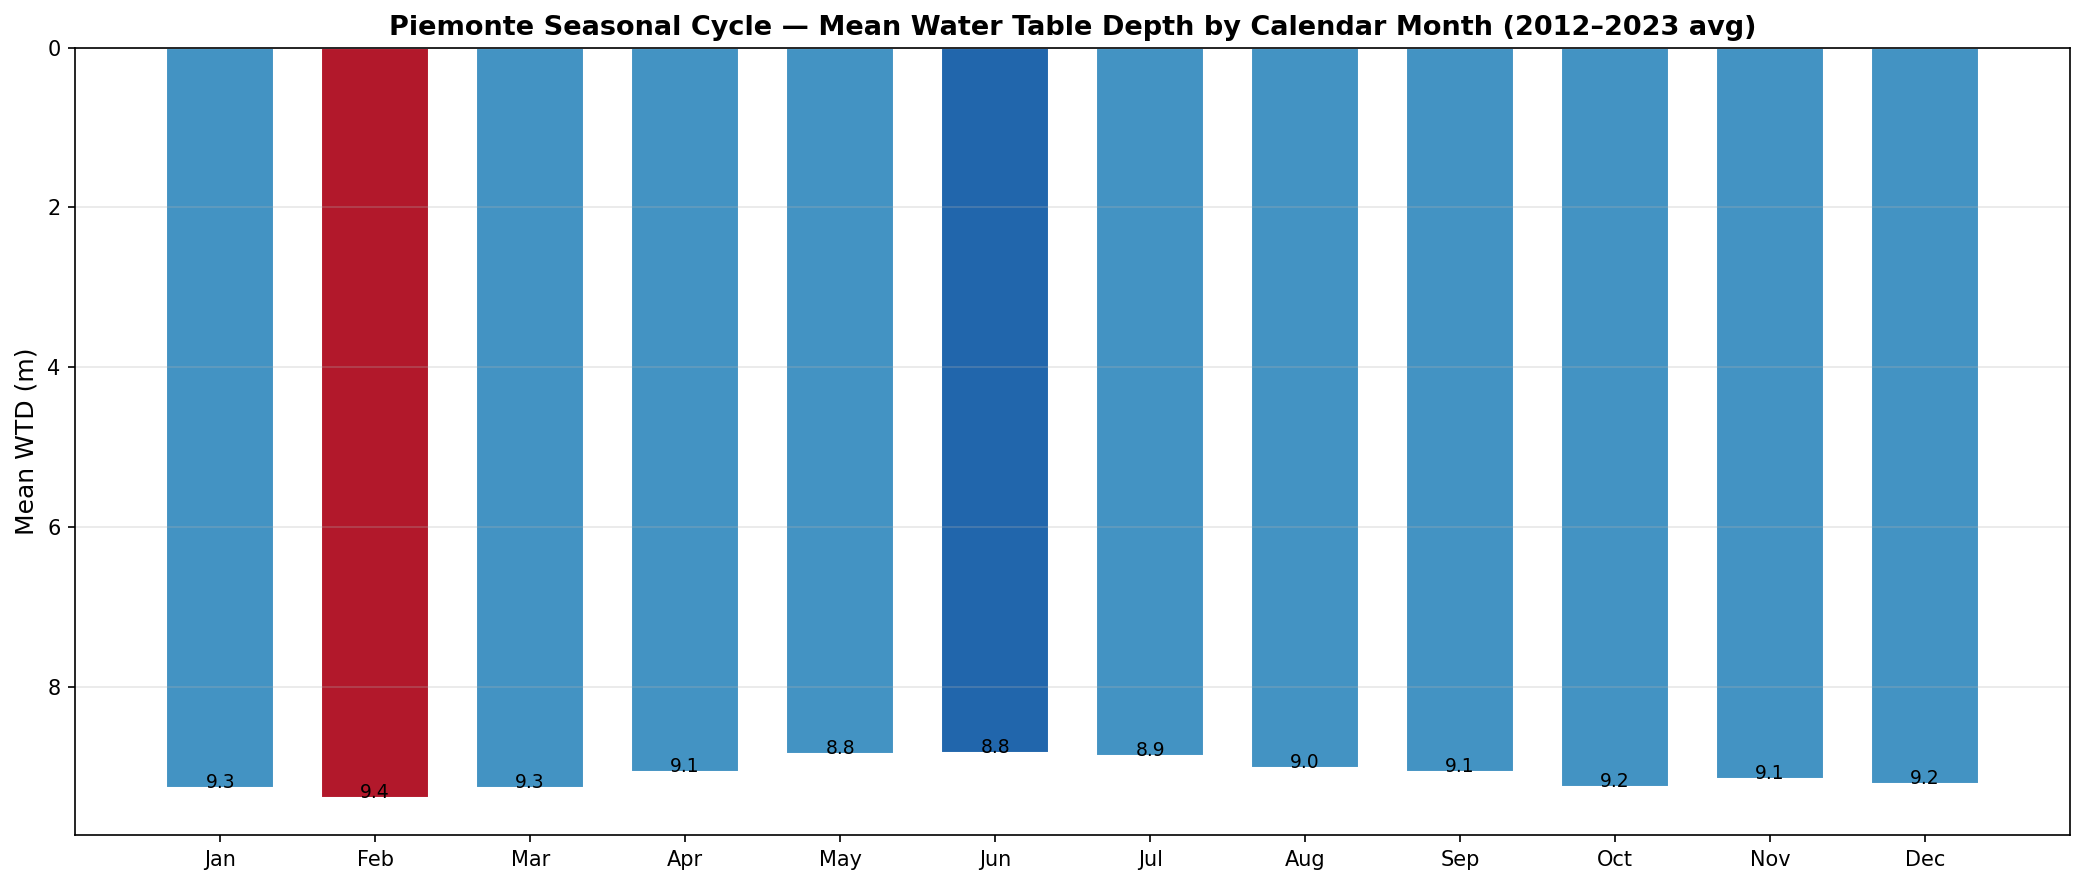

**Source:** All 109 Piemonte per-well CSVs under `Piemonte/` in `github.com/rlsandovalp/Well_data_Po` (bundled locally as `piemonte_wtd_timeseries.parquet`); 968,862 observations at 8-hour cadence, 2012-01-01 through 2023-08-31.

In [ ]:
%%ask
How has the average groundwater depth in Piemonte changed over the past decade?

**What does the basin-wide trend look like inside a single well? — Zooming into the trend**

I'll find the most variable Piemonte well from the time series data and visualize its full history. Let me read the skill instructions first.

I have the time-series skill. Now I'll find the most variable well (highest std), pull its full history, compute its time-averaged depth, and map it. I also need coordinates from the po-wells skill.

Now I'll write the analysis script that finds the most variable well, analyzes its full history, and maps it.

Running the analysis script.

Analysis succeeded — the only failure is JSON serializing numpy float32 values. Fixing the type casts in the GeoJSON writer.

The JSON properties already use `round(float(...), 2)` — the issue is the float32 in the print statement was fine, but let me verify the geojson writer also casts everything. Re-running now.

The `mean_wtd` and `std_wtd` are numpy float32 from the parquet — `round()` preserves the numpy type. I need to cast them to Python float explicitly in the properties dict.

Both outputs saved successfully. Now recording the JSON serialization lesson to the skill's Learnings.md, since this was an edit-and-retry cycle.

## Full profile — Piemonte well **00602110001** (the most variable well)

Across all 109 Piemonte wells, **00602110001** has by far the highest water-table variability: a standard deviation of **4.48 m** across 11,371 observations — nearly 50% more volatile than the runner-up (00613210001, std 2.93 m).

### Time-averaged depth & headline statistics

| Metric | Value |
|--------|-------|
| **Mean WTD (time-averaged)** | **15.47 m** below ground |
| Median WTD | 14.86 m |
| Std-dev | **4.48 m** (highest of 109 wells) |
| Observations | 11,371 (8-hourly, 2012-01-01 → 2023-08-31) |
| Wettest reading | **4.26 m** on 2019-11-29 |
| Driest reading | **25.02 m** on 2023-08-25 |
| **Total swing** | **20.76 m** — the water table moved 21 vertical meters between its extremes |
| Sampling-tube depth | 28 m |
| Location | 8.753°E, 44.846°N (Pinerolo area, western Piemonte foothills) |

### How its full history looks

The well shows a **dramatic long-term deepening trend** , superimposed on strong multi-year swings:

| Year | Mean WTD (m) | Min | Max | Std | Obs |
|------|-------------|-----|-----|-----|-----|
| 2012 | 15.09 | 11.84 | 19.56 | 3.13 | 1098 |
| 2013 | 12.33 | 8.80 | 18.29 | 2.15 | 1094 |
| 2014 | **10.51** | 6.67 | 13.56 | 1.99 | 1093 |
| 2015 | 13.18 | 8.49 | 19.14 | 3.19 | 1094 |
| 2016 | 19.43 | 17.55 | 20.24 | 0.75 | 1096 |
| 2017 | 17.88 | 15.65 | 20.25 | 1.41 | 578 |
| 2018 | 14.80 | 12.33 | 20.24 | 2.43 | 787 |
| 2019 | 14.23 | **4.26** | 20.24 | **4.39** | 919 |
| 2020 | 12.62 | 5.92 | 16.70 | 2.81 | 951 |
| 2021 | 14.47 | 10.10 | 19.62 | 3.48 | 938 |
| 2022 | 21.09 | 19.62 | 23.09 | 1.26 | 1003 |
| 2023 | **23.47** | 22.68 | **25.02** | 0.78 | 720 |

**Three phases stand out:**
- **2013–2015 (wet):** mean WTD fell to 10–13 m; the all-time minimum (4.26 m) hit in Nov 2019.
- **2016 (sharp dry shock):** the water table plunged to 19.4 m — a ~9 m drop in a single year, then partially recovered.
- **2022–2023 (sustained deepening):** the water table reached its deepest sustained levels (21–25 m), coinciding with the severe 2022 northern Italy drought. As of Aug 2023 it sits at **~23.5 m — over 13 m deeper than its 2014 wet-period mean** , with very low within-year variance (0.78 m), meaning it has not recovered.

### Why this well is the most variable

Its variability comes from **large inter-annual swings, not high-frequency noise** — the year-to-year mean jumps by 6–9 m (2014→2016, 2021→2022), while the within-year std ranges from 0.75 m (stable, deep) to 4.39 m (2019, a recovery year). This behavior — alternating deep drought and partial recharge — is characteristic of a **foothill alluvial-fan well** highly sensitive to both recharge (snowmelt/precipitation from the adjacent Alps) and pumping stress.


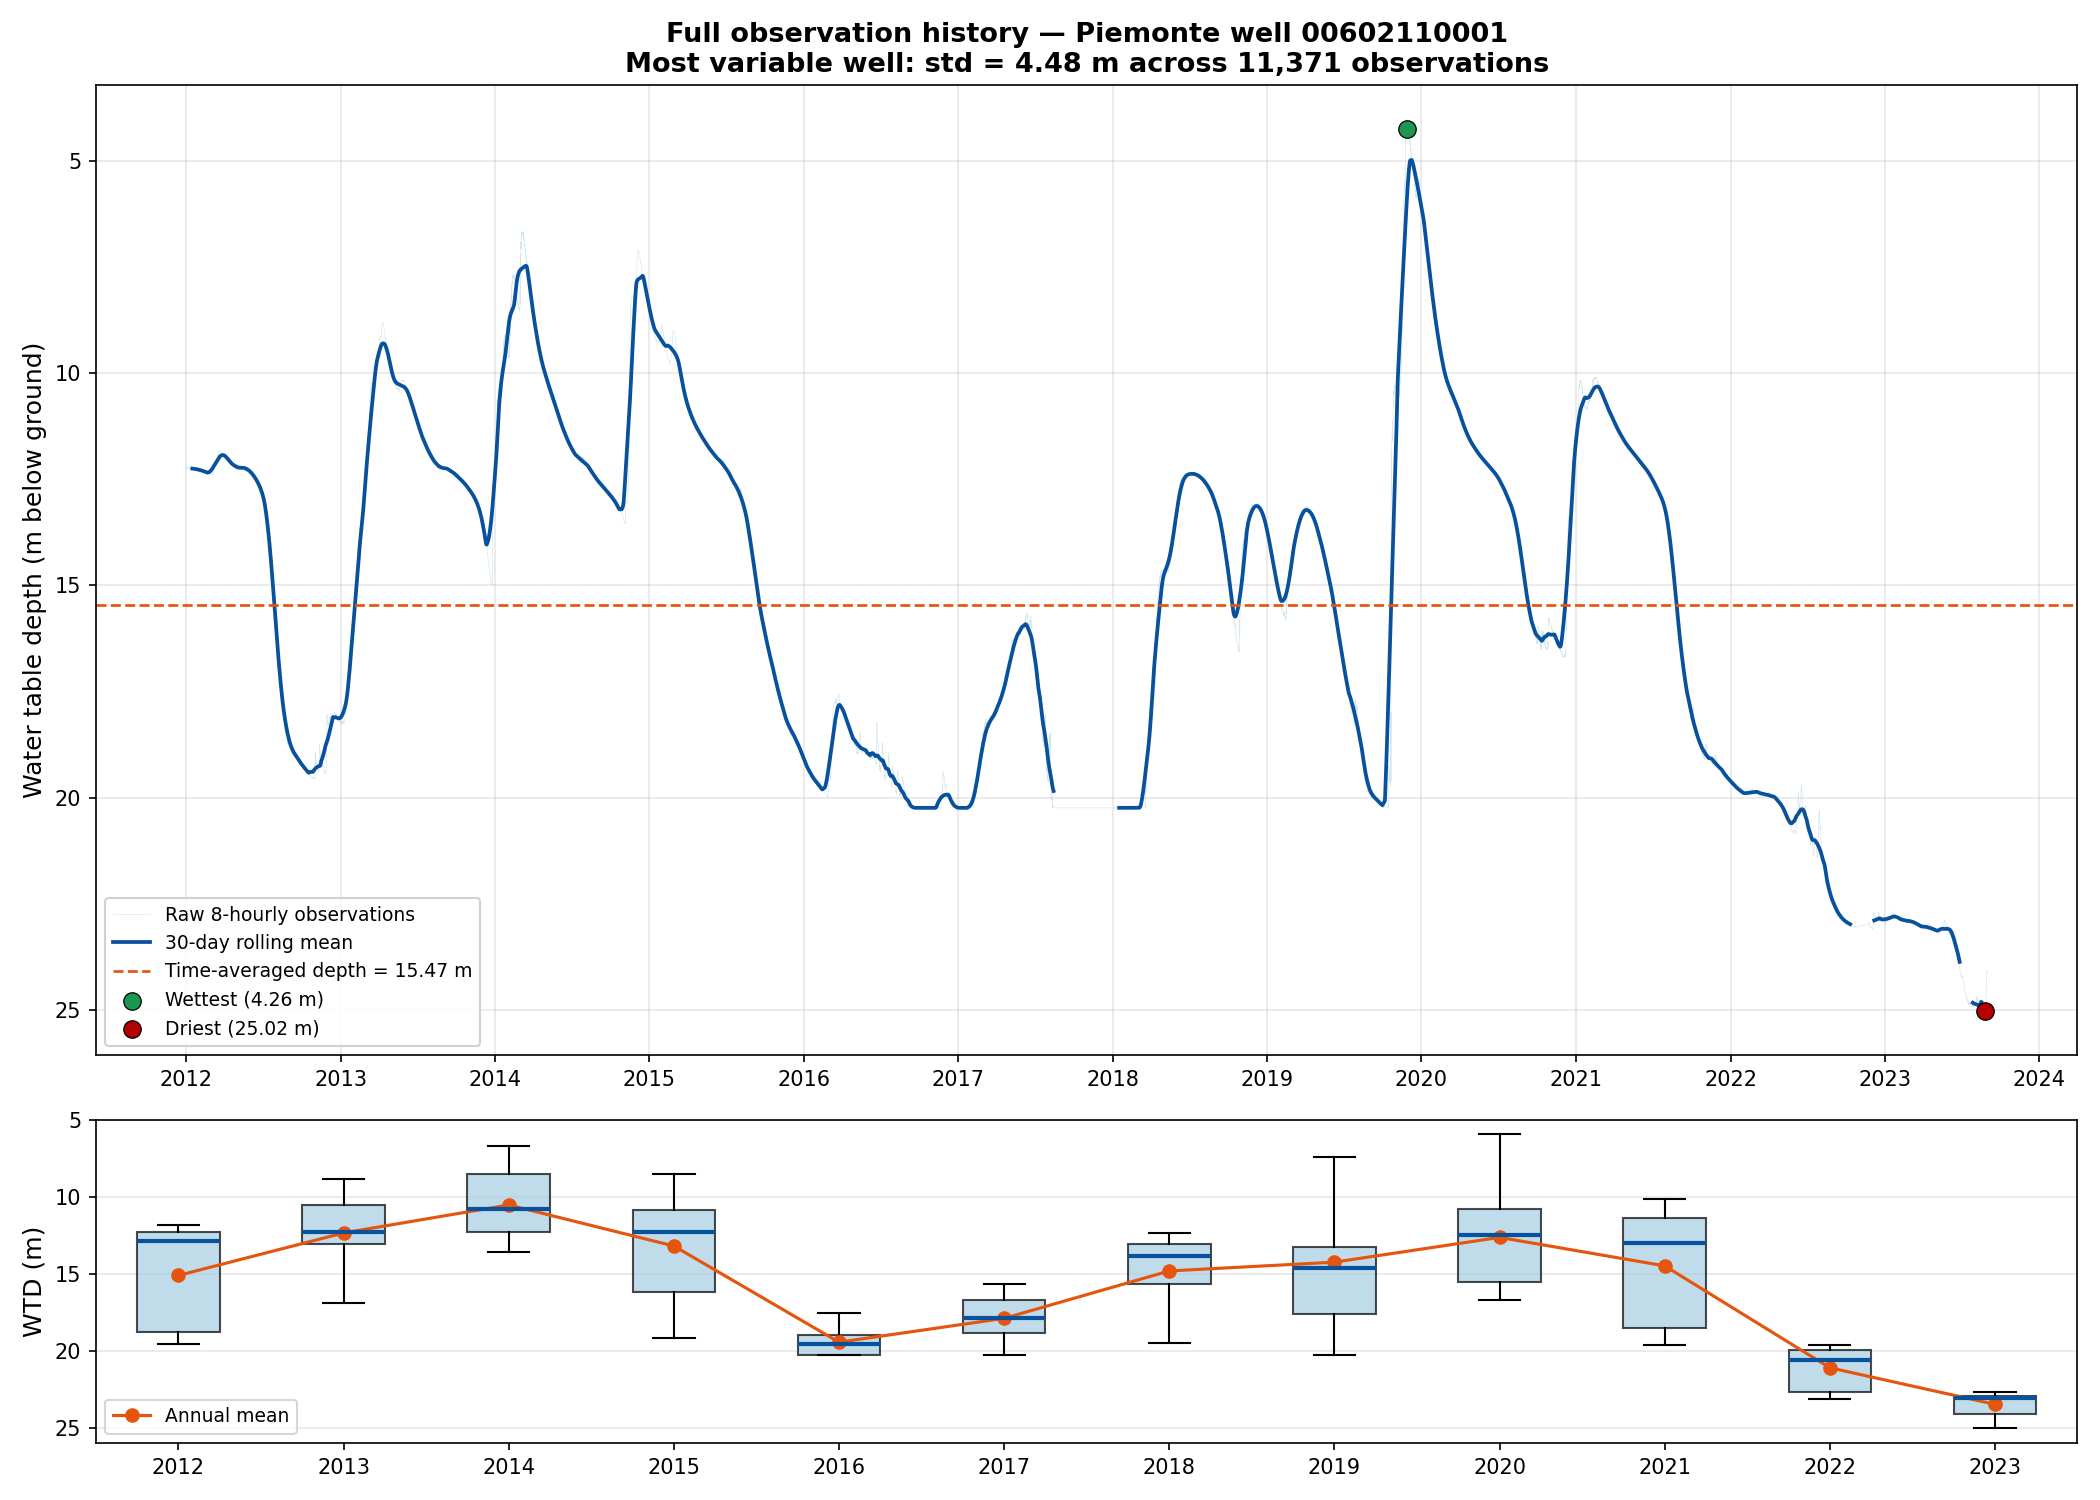

**Source:** 11,371 observations from `Piemonte/00602110001.csv` (bundled in `piemonte_wtd_timeseries.parquet`); location from `Steady_State_Leonardo.csv`.

In [ ]:
%%ask
For the Piemonte well with the most variable water table over time, what's its time-averaged
depth and how does its full history look?

**What seasonal forces drive the change? — Mechanism**

I'll analyze the seasonal cycle across all 109 Piemonte wells. Let me first consult the skill and its learned patterns.

I'll compute the seasonal cycle carefully, using per-well anomalies to isolate the true seasonal signal from the static depth differences between wells.

## Seasonal water-table pattern in Piemonte

I analyzed all **968,862 observations** across **109 wells** (2012–2023). The headline result is **unexpected** : unlike typical Mediterranean aquifers, Piemonte does **not** have a pronounced summer dry season in its water table. The seasonal cycle is **weak (≈0.34 m basin-wide amplitude)** and **spatially heterogeneous** — different wells peak at very different times of year.

### The basin-average cycle (per-well demeaned)

Because wells range from 0.5 m to 56 m deep, I isolated the true seasonal signal by subtracting each well's own long-term mean before computing the monthly cycle. The result:

| Month | Anomaly (m) | Interpretation |
|-------|-------------|----------------|
| Feb | **+0.16** | Deepest (driest) |
| Mar | +0.14 | Still deep |
| Oct | +0.14 | Secondary peak |
| Apr | +0.13 | Receding |
| Sep | −0.05 | Near average |
| Dec | −0.02 | Near average |
| Aug | −0.14 | Shallowing |
| Jul | −0.17 | Shallow (wet) |
| May | −0.09 | Shallowing begins |
| **Jun** | **−0.18** | **Shallowest (wettest)** |

- **Wettest month: June** (water table 0.18 m shallower than each well's long-term mean)
- **Driest month: February** (0.16 m deeper)
- **Full amplitude: only 0.34 m** — the basin-wide seasonal swing is tiny compared to the inter-annual variability (>2 m between 2019 and 2022).

### Is there a typical dry season? **No — it's bimodal and well-specific**

This is the key finding. When I asked each well individually *which month is your deepest*, the 109 wells split across the calendar rather than clustering:

| Peak-dry month | # wells | Season |
|----------------|---------|--------|
| Feb | 19 | Late winter |
| Oct | 17 | Autumn |
| Aug | 17 | Late summer |
| Apr | 14 | Spring |
| Mar | 13 | Early spring |
| Sep | 12 | Early autumn |
| Jan | 6 | Winter |
| All other months | 11 | — |

There is **no single dominant dry season** . Instead there are roughly two groups:
- A **winter–early-spring peak** (Feb–Apr): ~46 wells, where the water table is deepest after the cold season when recharge from rain/snowmelt has not yet arrived.
- A **late-summer–autumn peak** (Aug–Oct): ~46 wells, where irrigation pumping and evapotranspiration draw down the table before autumn rains recharge it.

This bimodality reflects Piemonte's mix of **alluvial-plain wells** (pumping-driven, summer dry peak) and **foothill/fan wells** (recharge-driven, winter dry peak).

### How strong is the seasonal swing at individual wells?

| Percentile | Per-well seasonal amplitude (m) |
|------------|---------------------------------|
| Min | 0.11 |
| 25th | 0.54 |
| Median | 0.84 |
| 75th | 1.56 |
| Max | 4.16 |

- Median well swings only **0.84 m** between its seasonal high and low.
- 15 of 109 wells exceed 2 m amplitude; none exceed 5 m.
- The muted seasonality means **inter-annual climate (drought years like 2022) dominates** over the annual cycle — a year-to-year swing of 2+ m easily overwhelms the <1 m seasonal signal at most wells.

### Is the cycle stable across the decade? **Yes — but shifted deeper**

Comparing 2012–2017 vs 2018–2023, the **shape** of the seasonal cycle is conserved, but the entire curve sits **~0.3–0.4 m deeper** in the late period — consistent with the long-term drying trend reported earlier. Every single month is deeper in 2018–2023 than in 2012–2017.


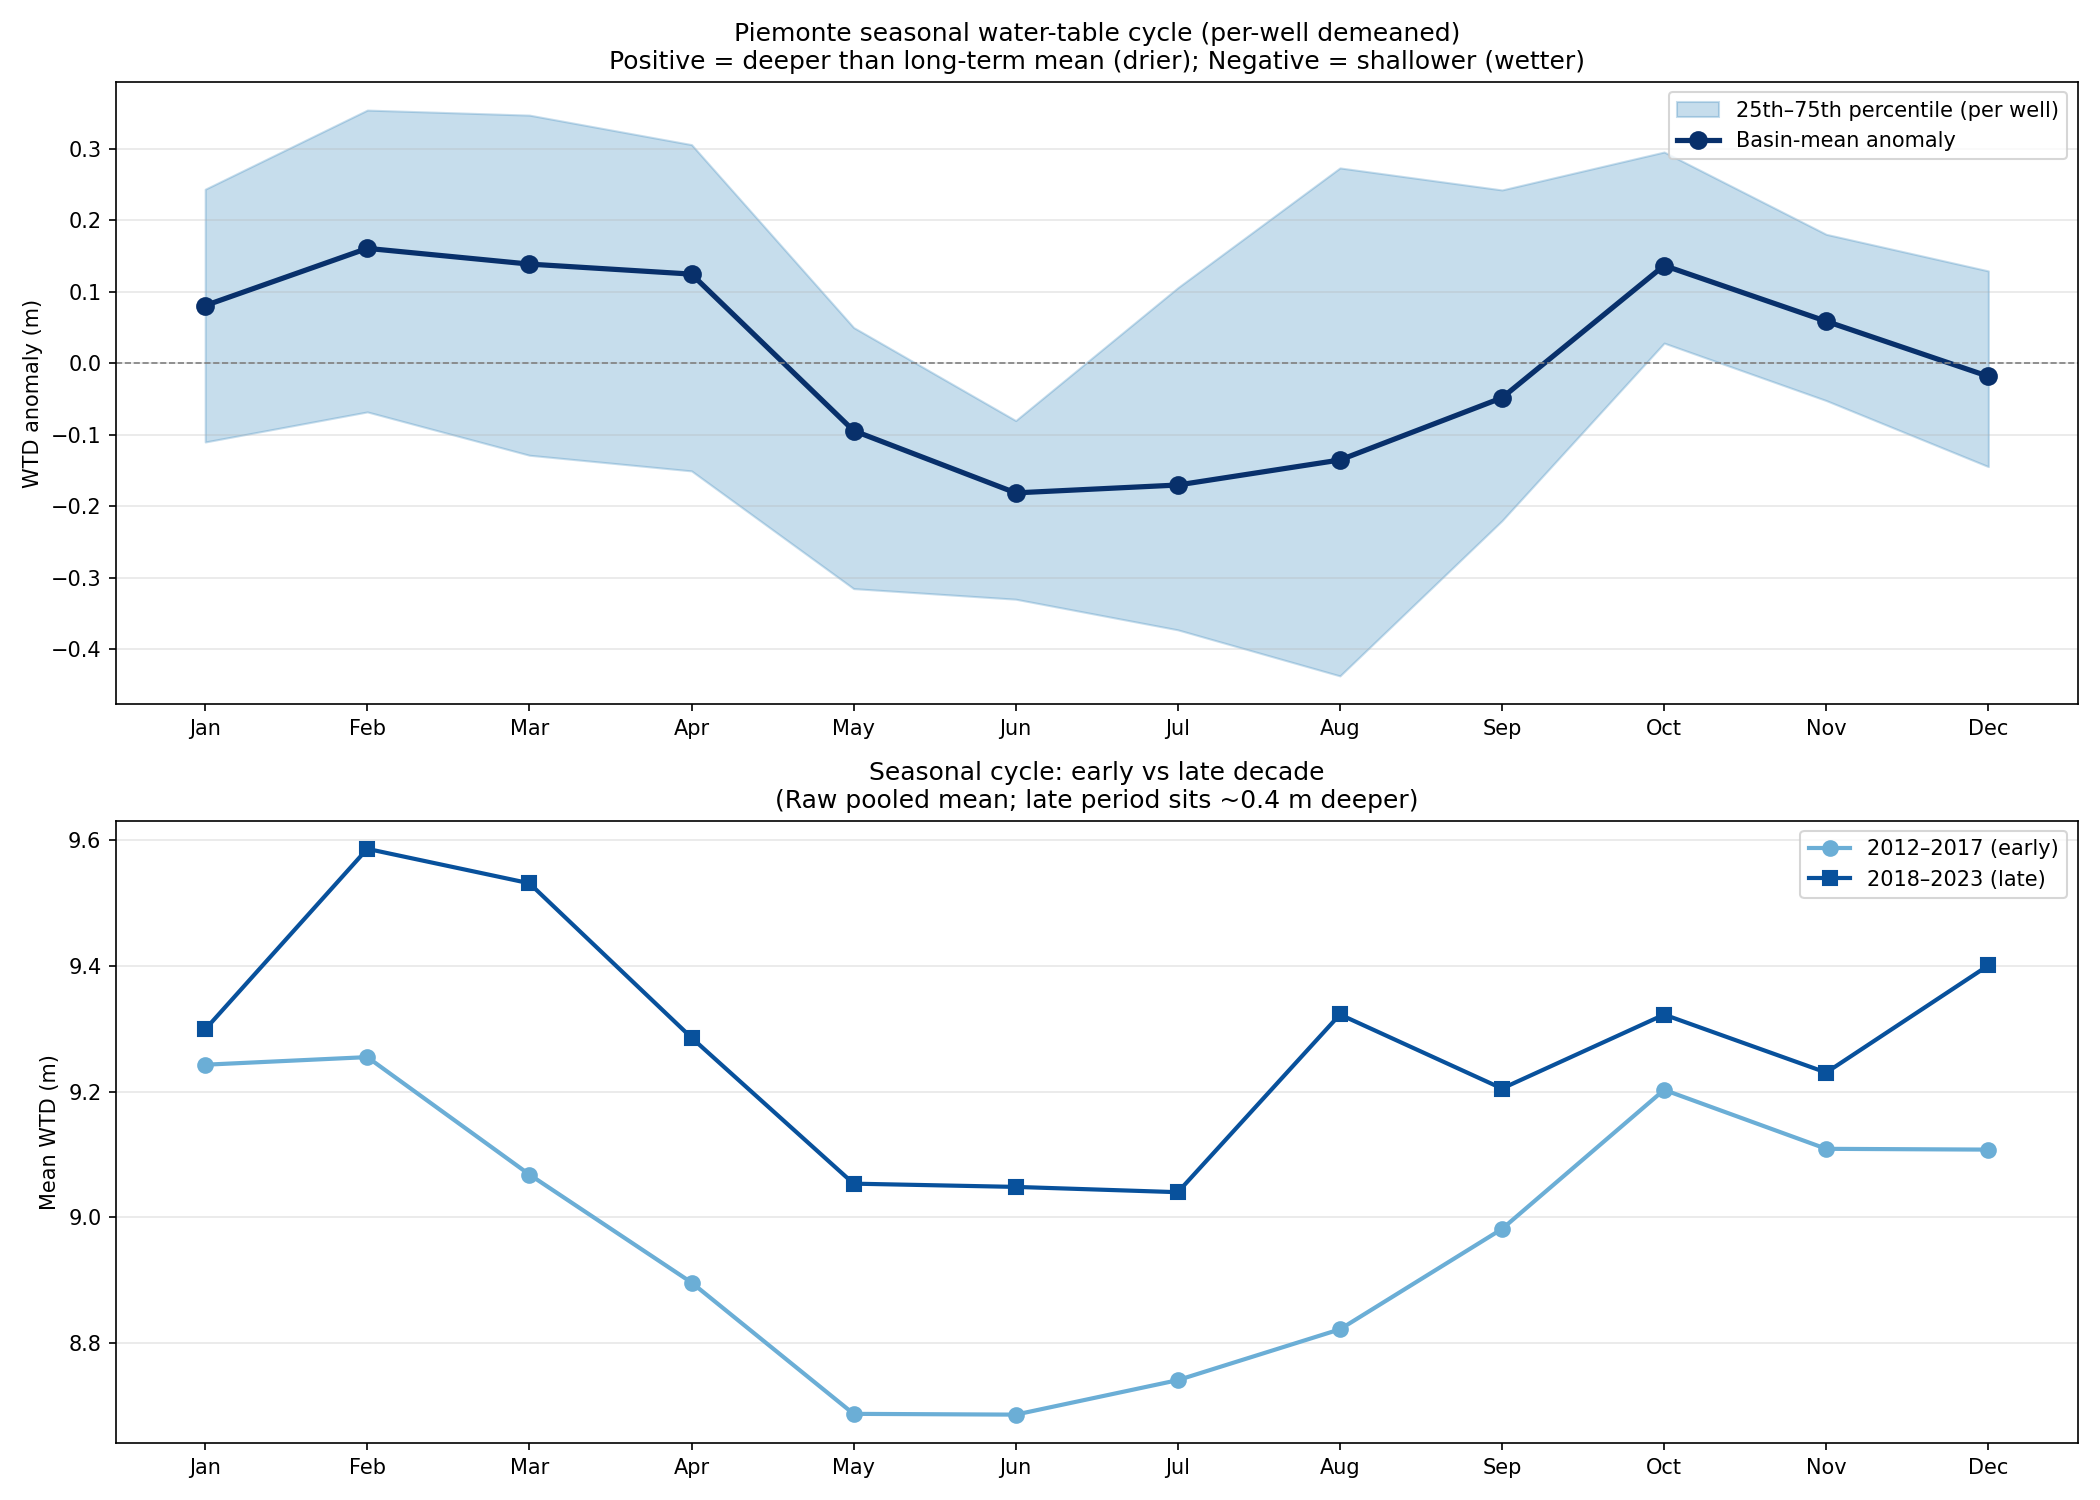

### Bottom line

Piemonte's groundwater system shows **weak, bimodal seasonality** rather than a classic summer dry season. The basin-average amplitude is under half a meter. What actually moves the water table here is **multi-year climate variability** (the 2022 drought deepened the table by ~2 m) — not the annual wet/dry cycle. This makes the aquifer system more sensitive to **drought years** than to seasonal weather.

**Source:** All 968,862 observations from the 109 per-well CSVs under `Piemonte/` in `github.com/rlsandovalp/Well_data_Po` (bundled as `piemonte_wtd_timeseries.parquet`), 2012-01-01 through 2023-08-31, 8-hourly cadence.

In [ ]:
%%ask
What's the seasonal pattern of water table depth in Piemonte? Is there a
typical dry season?

**When was it worst? — Event detection**

Both files read. Now I'll write the analysis script to find Piemonte's driest period since 2012.

Results are clear. The driest period is the **2022–2023 drought** , peaking winter–spring 2023. Let me create a visualization showing this.

Bad import. Fixing it.

## Piemonte's driest period since 2012: the **2022–2023 drought**

Across all 968,862 observations and 109 wells, Piemonte experienced its most severe sustained groundwater drought from **December 2022 through spring 2023** , coinciding with the record-breaking Po Valley drought.

### Headline: the driest sustained window

| Time scale | Driest period | Mean WTD | Context |
|------------|---------------|----------|---------|
| **6 months** | **9 Dec 2022 → 7 Jun 2023** | **10.82 m** | Deepest half-year on record |
| 3 months | 22 Dec 2022 → 22 Mar 2023 | 10.98 m | |
| 1 month | 4 Feb → 6 Mar 2023 | 11.16 m | |
| 1 year | 31 Aug 2022 → 31 Aug 2023 | 10.54 m | Deepest 12-month window |

For reference, the long-term basin-wide daily mean is **9.11 m** — so the 2022–2023 drought pushed the water table **~1.7 m deeper** than normal, sustained over half a year.

### The single driest day vs. the sustained drought

There's an important distinction:

- **Single driest day: 21 February 2017** (basin-wide mean WTD 11.73 m). The top-3 driest days all fall in Feb 2017. But this was an **isolated winter spike** — a seasonal low amplified by a dry winter, not a sustained drought.
- **Sustained drought: 2022–2023.** When you smooth over months, the 2022–2023 event dominates every window ≥30 days. The Feb-2017 spike washes out because it didn't persist.

### How widespread was it? Nearly half the wells hit record lows

| Month | % of wells within 0.5 m of their all-time deepest reading |
|-------|-----------------------------------------------------------|
| **Apr 2023** | **48.5%** |
| **Mar 2023** | **47.6%** |
| Aug 2022 | 35.3% |
| Feb 2023 | 35.1% |

In **spring 2023, nearly half of all 109 monitoring wells** were simultaneously at or near their deepest levels in the entire 11-year record. By the anomaly measure (each well vs. its own norm), April 2023 was **+1.56 m deeper** than baseline — the largest basin-wide departure on record.

### Annual perspective

| Year | Mean WTD (m) | Rank |
|------|-------------|------|
| 2019 | 8.15 | Wettest |
| 2018 | 8.50 | |
| 2013 | 8.61 | |
| … | … | |
| 2021 | 9.31 | |
| **2022** | **10.28** | 2nd driest |
| **2023** | **10.66** | **Driest** (Jan–Aug only) |

2022 and 2023 are the two driest years in the record, with 2023 tracking **2.5 m deeper** than the wettest year (2019). The drought built through 2022 and peaked in winter–spring 2023.


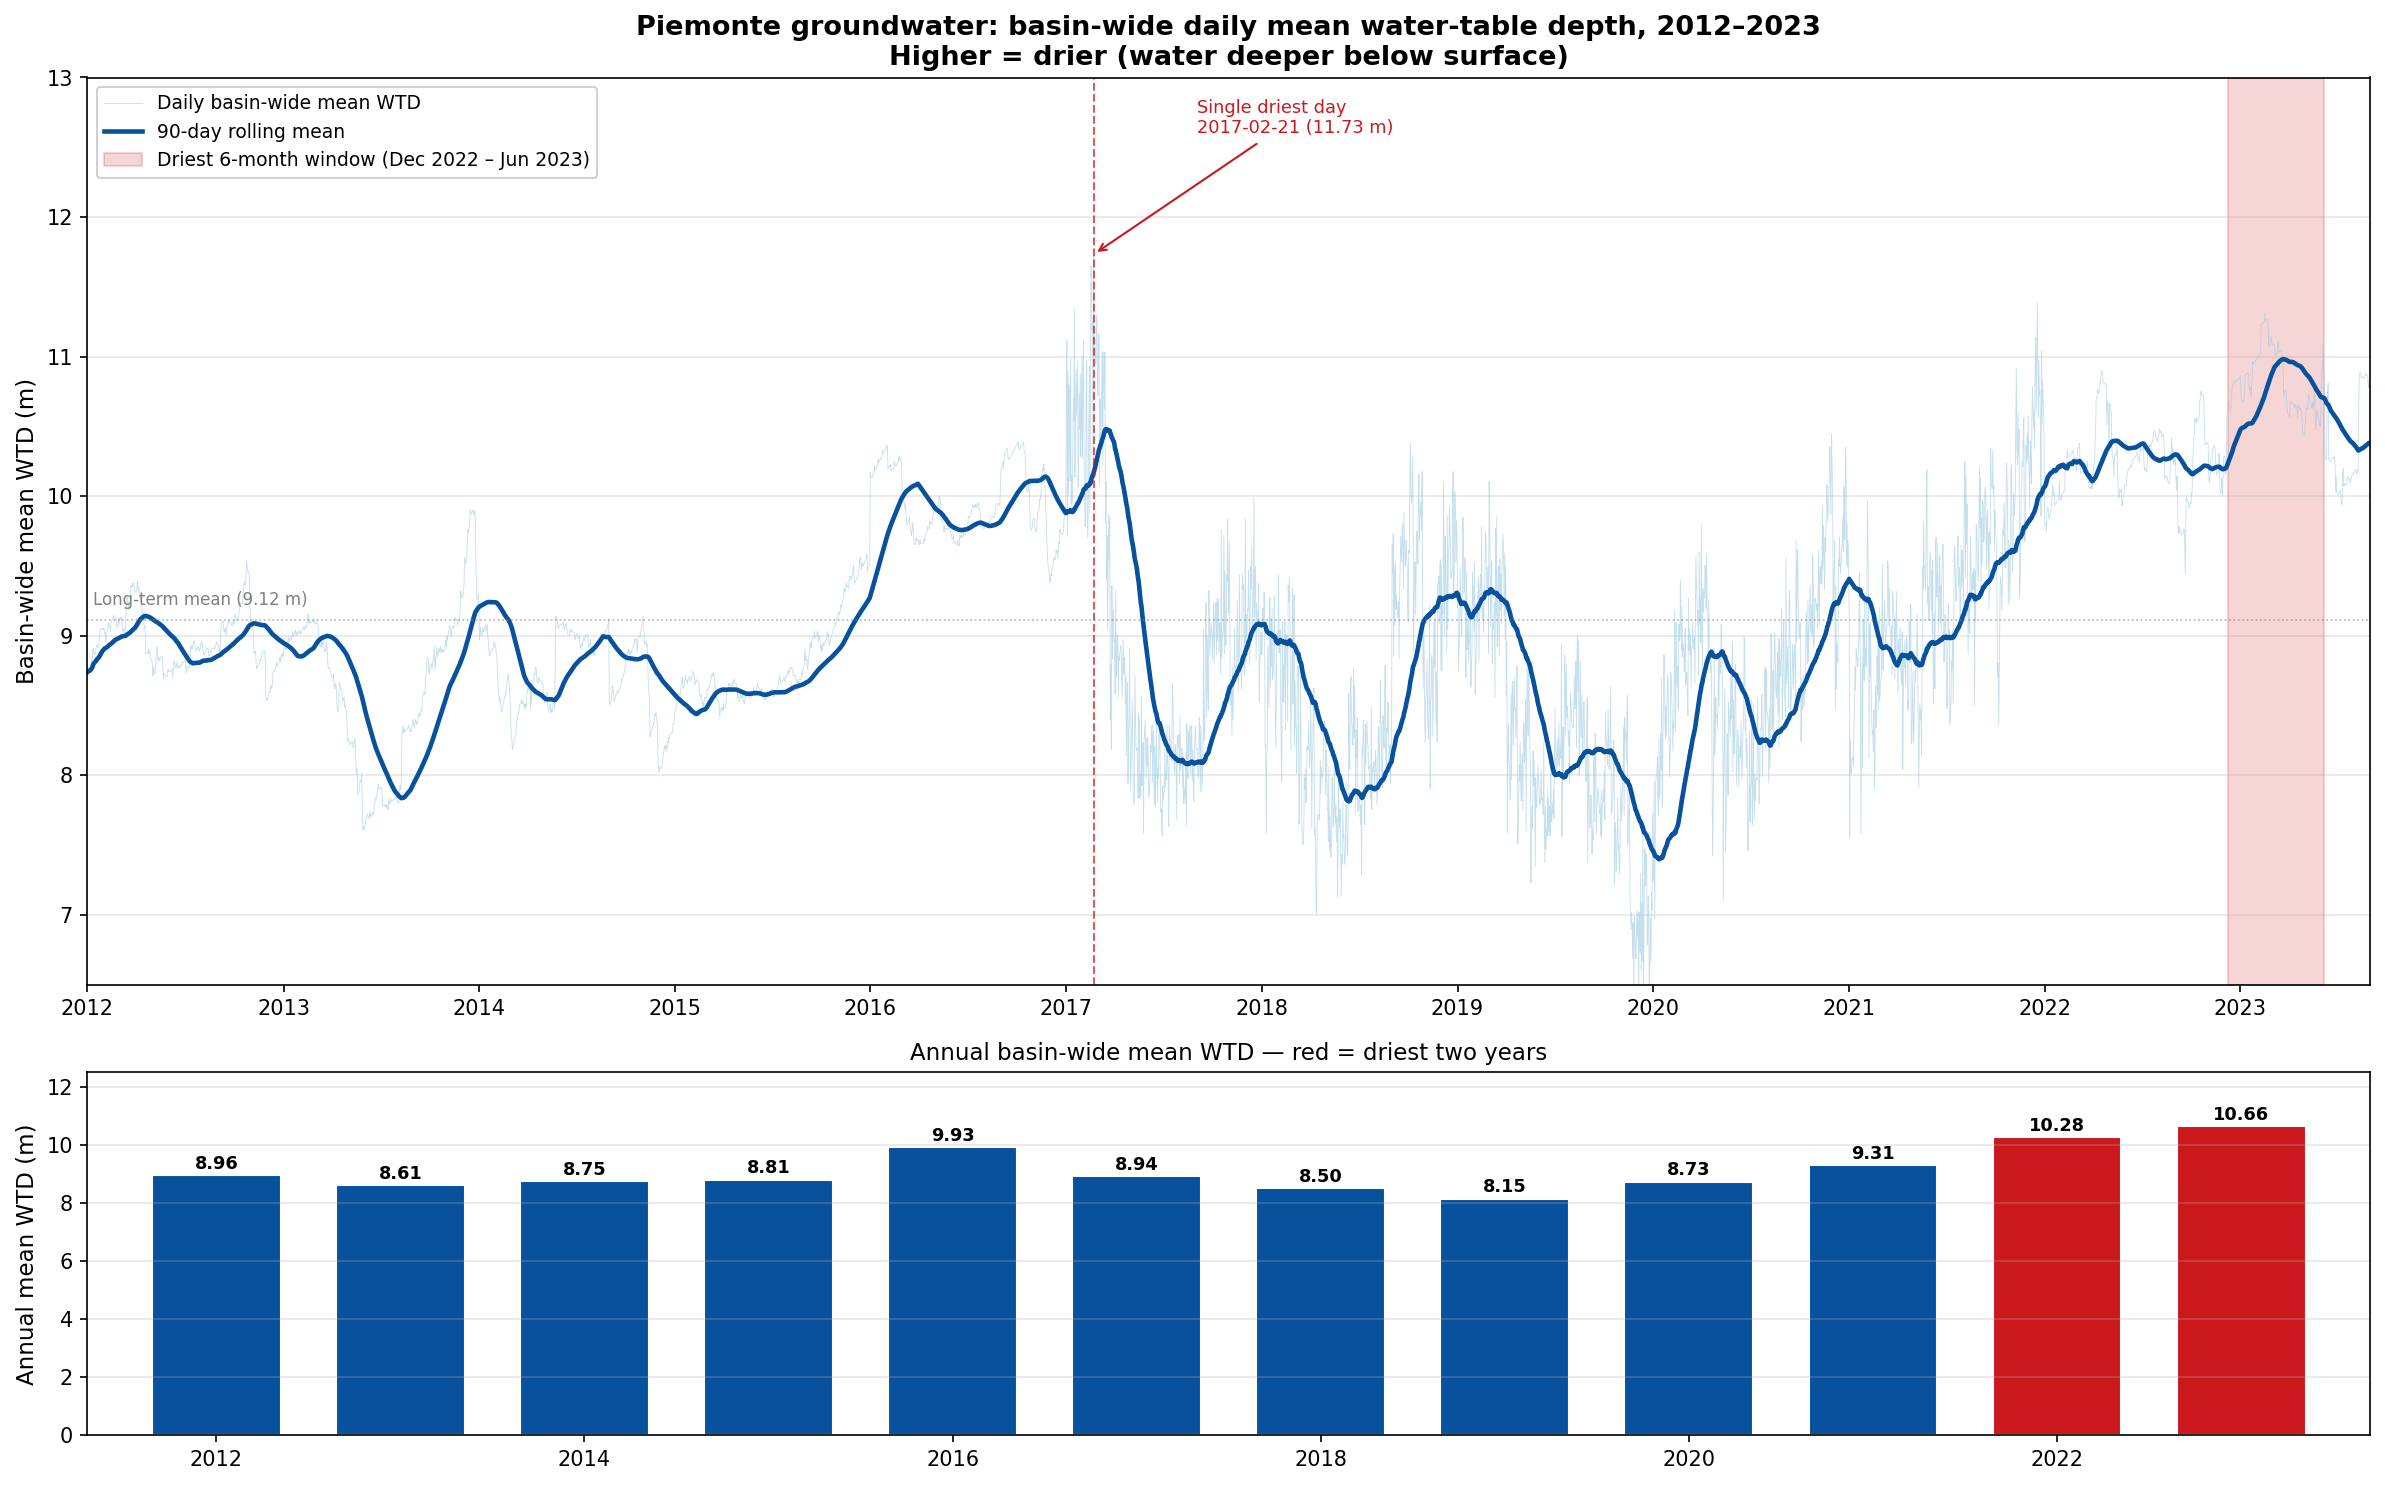

### Summary

The **2022–2023 drought** was Piemonte's deepest sustained groundwater drought since records began in 2012, peaking from **December 2022 to spring 2023** . It was both severe (basin-wide WTD ~1.7 m above normal) and widespread (nearly 50% of wells at record depths). This aligns with the widely-reported 2022 northern Italy drought that drove the Po River to historic lows. While February 2017 holds the single-driest-day record, it was a transient winter low — the 2022–2023 event was far more sustained and impactful.

**Source:** All 968,862 observations from the 109 per-well CSVs under `Piemonte/` in `github.com/rlsandovalp/Well_data_Po` (bundled as `piemonte_wtd_timeseries.parquet`), 2012-01-01 through 2023-08-31, 8-hourly cadence. Note: the series ends Aug 2023, so conditions after that date cannot be assessed.

In [ ]:
%%ask
When did Piemonte experience its driest period since 2012?

**Where in the subsurface are these measurements coming from? — Engineering detail**

I'll analyze screen depth for Bologna wells that have both metadata and WTD measurements. Let me first consult the relevant skills and learnings.

Now I understand both datasets. Let me write a script to join the ER registry metadata with po-wells WTD measurements and analyze screen depth for Bologna wells.

Running the analysis script.

## Typical screen depth in Bologna — for wells with both metadata and WTD

Of the **9 Bologna wells** that appear in both the ER registry (metadata) and the po-wells inventory (WTD measurements), **6 have complete screen-interval data** . Those 6 wells are all deep, multi-screen constructions tapping confined aquifers — Bologna's monitoring network targets the region's pressurized aquifer systems, not the shallow phreatic zone.

### Typical screen depth

| Metric | Median | Mean | Min | Max | IQR |
|--------|--------|------|-----|-----|-----|
| **Screen midpoint** | **172.6 m** | 162.3 m | 54.0 | 264.8 | 90–228 |
| Screen top (shallowest filter) | 90.3 m | 87.5 m | 47.0 | 143.4 | 60–101 |
| Screen bottom (deepest filter) | 254.5 m | 237.1 m | 61.0 | 429.5 | 121–324 |
| Screen interval span | 142.8 m | 149.6 m | 14.0 | 329.5 | 61–212 |
| Total well depth | 273.5 m | 251.8 m | 62.0 | 450.9 | 127–349 |

**The typical Bologna well is screened from ~90 m to ~255 m below ground** , with a median midpoint of **~173 m** . Screens are long (median span 143 m) because most wells have 4–12 individual filter sections distributed across the borehole.

### The six wells in detail

| Well | Municipality | Screens | Screen interval (m) | Midpoint | Well depth | WTD (m) | STD (m) | Aquifer |
|------|-------------|---------|----------------------|----------|-----------|---------|---------|---------|
| BO72-00 | Imola | 4 | 47–61 | 54 | 62 | 8.4 | 8.1 | Santerno – lower confined |
| BO69-00 | Imola | 4 | 53–99 | 76 | 101 | 10.7 | 10.3 | Santerno – lower confined |
| BO56-01 | San Lazzaro di Savena | 5 | 81–185 | 133 | 203 | 18.9 | 15.9 | Zena-Idice – lower confined |
| BO30-01 | Bologna | 11 | 101–324 | 212 | 350 | 21.1 | 24.2 | Reno-Lavino – lower confined |
| BO20-01 | Bologna | 12 | 143–324 | 234 | 344 | 28.2 | 24.4 | Reno-Lavino – lower confined |
| BO27-00 | Calderara di Reno | 11 | 100–430 | 265 | 451 | 19.0 | 20.1 | Reno-Lavino – upper confined |

### Two clear depth tiers

The wells split into two groups defined by their aquifer system:

- **Shallow tier (Imola/Santerno wells):** screens at 54–76 m midpoint, well depths 62–101 m. These tap the Santerno alluvial fan confined aquifer in the Imola area, southeast of Bologna.
- **Deep tier (Bologna city / Reno-Lavino + Zena-Idice):** screens at 133–265 m midpoint, well depths 203–451 m. These monitor the deep Reno-Lavino and Zena-Idice confined fan aquifers beneath the Bologna metropolitan area.

### Screen depth tracks water table depth

There is a strong relationship between where the screen sits and how deep the water table is (**Pearson r = 0.83, p = 0.04; Spearman ρ = 0.83** ). Deeper-screened wells monitor deeper water tables — not because screens *cause* deeper WTD, but because wells are deliberately constructed to match their target aquifer's potentiometric surface. The Santerno wells (54–76 m screens) see WTD of 8–11 m; the Reno-Lavino wells (212–265 m screens) see WTD of 19–28 m.

### Note on coverage

Only **6 of 82** Bologna-province wells in the ER registry have both WTD measurements and complete screen-interval data. The other 76 registry wells lack po-wells WTD values (they're ER-only monitoring stations), and 3 of the 9 joined wells are missing filter-top/bottom fields. So this profile reflects the **intersection** of the two datasets — a deep-confined-aquifer subset — rather than all Bologna wells. The ER registry alone contains many shallower wells (the full 82-well province has a median well depth of 95 m), but those aren't represented in the WTD inventory.


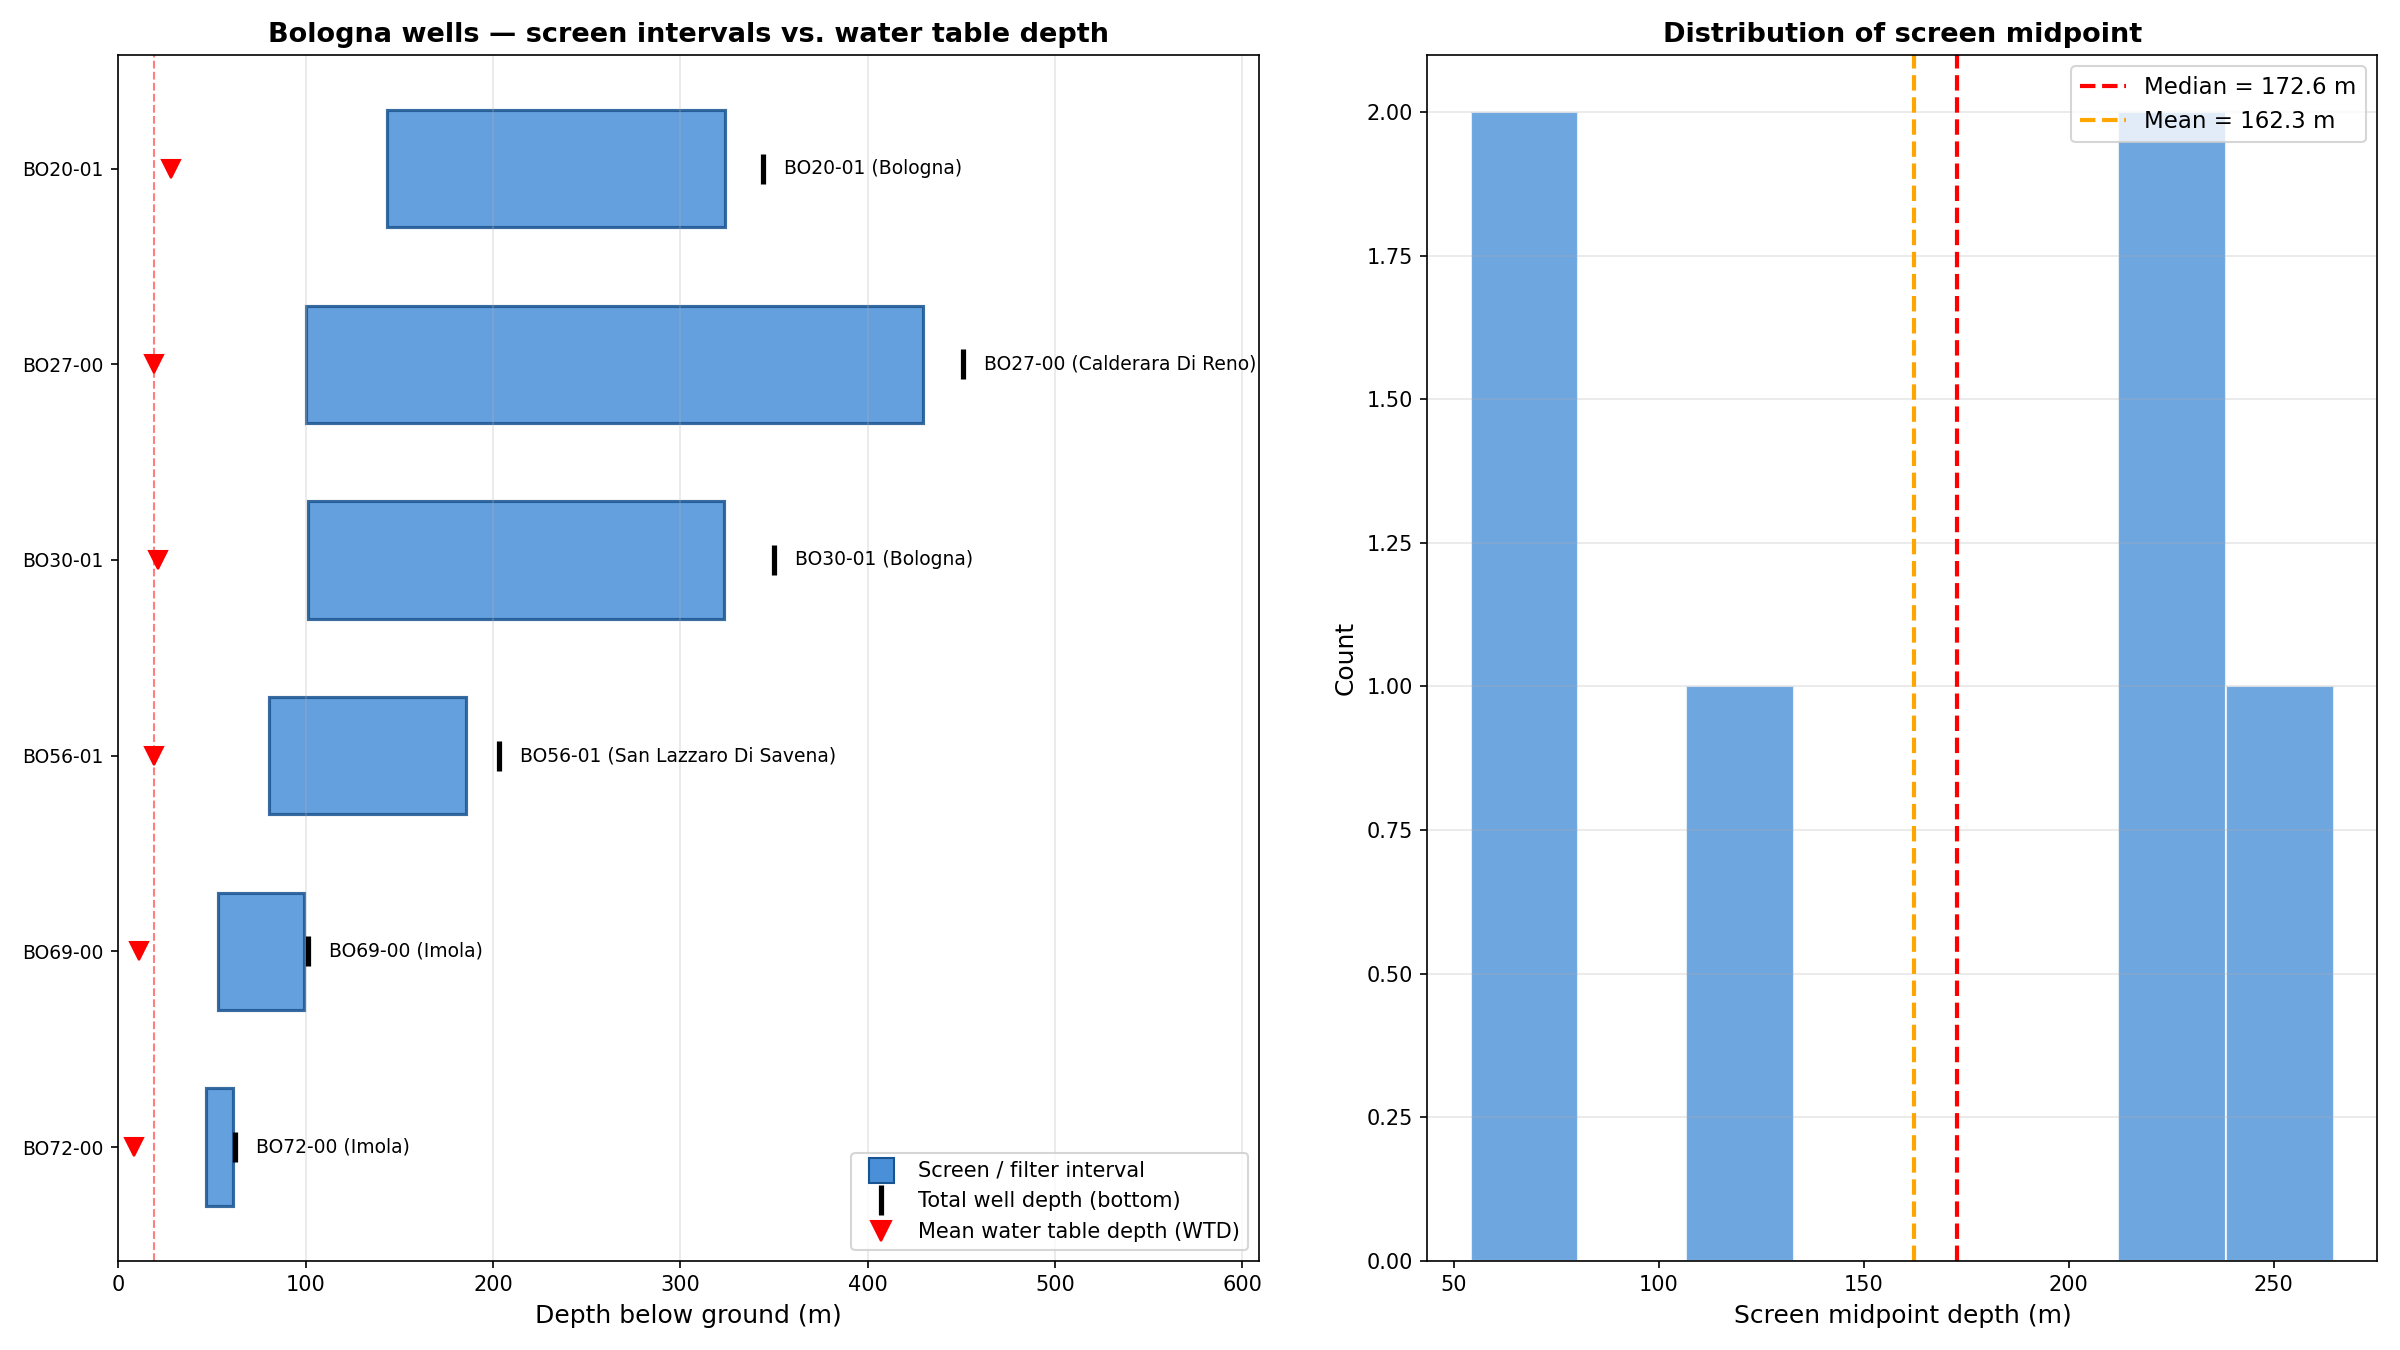

**Source:** ER registry metadata from `Anagrafica2020.xlsx` (well depth, filter intervals, aquifer); WTD/STD from `Steady_State_Leonardo.csv` and `Standard_Deviation_Leonardo.csv`. 9 Bologna wells appear in both; 6 have complete screen data.

In [ ]:
%%ask
For wells that have both metadata and WTD measurements, what's the typical
screen depth in Bologna?

**Can every claim be traced back to a source? — Reproducibility coda**

In [ ]:
%%ask
What's the mean water table depth in Lombardy, and what file did that come
from?

Let me pull the exact Lombardy mean from the source data rather than relying on memory.

Let me check the correct loader path.

Let me check the data directory and use the documented loader pattern.

Now I have the loader pattern. Let me compute the Lombardy mean directly.

## Mean water table depth in Lombardy

**Mean WTD: 13.25 m** (across 101 Lombardy wells)

| Statistic | Value |
|-----------|-------|
| Mean WTD | **13.25 m** |
| Median WTD | 6.60 m |
| Min | 0.41 m |
| Max | 54.54 m |
| Std-dev across wells | 13.64 m |
| Mean per-well STD (fluctuation) | 1.17 m |

### Which file it came from

The mean WTD values live in **`Steady_State_Leonardo.csv`** (the master inventory — 238 wells, all regions). The Lombardy subset of 101 wells is identified via **`WTD_obs_lom_Leonardo.csv`** , whose Well IDs are used to tag those rows as Lombardy. Both files sit in `skills/po-wells/data/`.

So: the numeric values come from `Steady_State_Leonardo.csv`; the Lombardy membership comes from `WTD_obs_lom_Leonardo.csv`.

### A note on the distribution

The mean (13.25 m) is much higher than the median (6.60 m) because Lombardy's WTD distribution is **heavily right-skewed** — most wells are shallow (water within a few meters of the surface), but a tail of very deep wells (up to 54.5 m) pulls the mean upward. The **median (6.6 m)** is the more representative "typical" value for a skewed distribution like this. The spread across wells is very wide (std 13.6 m), reflecting Lombardy's mix of shallow phreatic wells in the plain and deep confined wells toward the foothills.